# **4.x Notebook**

Comprehensive (hopefully) notebook for project up to the current point. WIP
by Jack Phelan  




## Table of Contents
1. [Setup](#setup)
2. [Data Preparation](#data-preparation)
   - [Loading Encoded Baseline Dataset](#loading-default-df-and-applying-eda-preprocessing-steps)
   - [EFA Factor Dataset](#creating-factor-transformed-dataset-for-10-dataset)
   - [CFA Factor Dataset](#creating-cfa-based-dataset-with-v1-base)
3. [Feature Importances: EFA & CFA Datasets](#feature-importances-of-efa-and-cfa-datasets)
   - [EFA Dataset Feature Importances](#efa-dataset-feature-importances)
   - [CFA Dataset Feature Importances](#cfa-dataset-feature-importances)
   - [Top Feature Dataset Creation](#top-feature-dataset-creation)
4. [MLFlow Integrations](#mlflow-integrations)
5. [SMOTETomek Resampled Dataset Comparison](#smotetomek-resampled-dataset-comparison)


## **Setup**

In [ ]:

# ── data & numeric ────────────────────────────────────────────────────────────
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ── ML ────────────────────────────────────────────────────────────────────────
import joblib
import shap
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, average_precision_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import mlflow
import mlflow.data
import mlflow.sklearn
from factor_analyzer import FactorAnalyzer, ConfirmatoryFactorAnalyzer, ModelSpecificationParser

# ── project ───────────────────────────────────────────────────────────────────
from src.features import raw_data_loader, feature_encoder
from src.features.irt_scorer import grm_score_eap
from src.modeling.eval import plot_permutation_importance
from src.utils.data_utils import convert_ahi
from src.visualization.plots import efa_elbow_plot


In [ ]:

# ── MLflow helpers ────────────────────────────────────────────────────────────
_BASE_TAGS = {"notebook": "4fe", "task": "binary-classification", "target": "ahi>=15"}

def _setup_experiment(name, tags):
    """Create/get experiment, set tags (merged with base tags), delete old runs."""
    exp = mlflow.set_experiment(name)
    mlflow.set_experiment_tags({**_BASE_TAGS, **tags})
    _client = mlflow.MlflowClient()
    for _run in mlflow.search_runs(experiment_ids=[exp.experiment_id], output_format="list"):
        _client.delete_run(_run.info.run_id)
    mlflow.sklearn.autolog(log_models=False, silent=True)
    return exp


def _run_mlflow_trials(trials, model_configs, extra_run_tags=None, log_shap=True):
    """Train each (dataset × model) pair and log to the active MLflow experiment."""
    print(f"{'dataset':<25}  {'model':<6}  {'acc':>6}  {'auc':>6}  {'f1':>6}  {'auprc':>6}  {'n_features':>10}")
    print("-" * 78)
    for name, mlflow_ds, X_train, X_test, y_train, y_test in trials:
        for model_name, (ModelClass, params) in model_configs.items():
            tags = {"dataset": name, "model_type": model_name}
            if extra_run_tags:
                tags.update(extra_run_tags)
            with mlflow.start_run(run_name=f"{name}_{model_name}"):
                mlflow.set_tags(tags)
                mlflow.log_input(mlflow_ds, context="training")
                mlflow.log_param("n_features", X_train.shape[1])

                model = ModelClass(**params)
                model.fit(X_train, y_train)

                y_pred = model.predict(X_test)
                y_prob = model.predict_proba(X_test)[:, 1]

                acc   = accuracy_score(y_test, y_pred)
                auc   = roc_auc_score(y_test, y_prob)
                f1    = f1_score(y_test, y_pred)
                auprc = average_precision_score(y_test, y_prob)
                mlflow.log_metrics({"test_accuracy": acc, "test_roc_auc": auc, "test_f1": f1, "test_auprc": auprc})

                if log_shap:
                    explainer = shap.TreeExplainer(model)
                    shap_vals = explainer(X_test)
                    sv = shap_vals[..., 1] if shap_vals.values.ndim == 3 else shap_vals
                    mean_shap = pd.Series(np.abs(sv.values).mean(axis=0), index=X_test.columns)
                    mlflow.log_metrics({f"shap_{col}": float(v) for col, v in mean_shap.items()})
                    shap.plots.bar(sv, max_display=15, show=False)
                    mlflow.log_figure(plt.gcf(), "shap_bar.png")
                    plt.close("all")

                cm_fig, cm_ax = plt.subplots()
                ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=cm_ax, colorbar=False)
                cm_ax.set_title(f"{name} — {model_name}")
                mlflow.log_figure(cm_fig, "confusion_matrix.png")
                plt.close(cm_fig)

                print(f"{name:<25}  {model_name:<6}  {acc:>6.3f}  {auc:>6.3f}  {f1:>6.3f}  {auprc:>6.3f}  {X_train.shape[1]:>10}")


## **Data Preparation**


### Loading default df and applying EDA preprocessing steps

In [3]:
# This is the default 1.0 dataset that will be iterated upon in future experiments.
raw_df = raw_data_loader.load_and_clean_raw("../..")
encoded_df = feature_encoder.encode_features(raw_df)
encoded_df = encoded_df.drop(columns=["ess_total_score", "isi_total_score"])
encoded_df.to_csv("../../data/processed/mlflow/mlflow_dataset_v1.csv", index=False)

### Creating factor transformed dataset for 1.0 dataset

In [4]:
# performing factor analysis
factor_analyzer = FactorAnalyzer(n_factors=18, rotation="quartimax")

encoded_df  = pd.read_csv("../../data/processed/mlflow/mlflow_dataset_v1.csv")
encoded_features = encoded_df.drop(columns=["ahi"])
encoded_target = encoded_df["ahi"]
factor_analyzer.fit(encoded_features)
fa_loadings = pd.DataFrame(factor_analyzer.loadings_, index=encoded_features.columns
)

In [5]:
# display top n features per factor loading
n = 7

top_features = {}
for factor in fa_loadings.columns:
    top = fa_loadings[factor].abs().nlargest(n)
    top_features[factor] = [f"{feat}  ({fa_loadings.loc[feat, factor]:+.2f})" for feat in top.index]

pd.DataFrame(top_features, index=[f"#{i+1}" for i in range(n)])


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
#1,fati_interferes_with_work_fam_social_fss (+0.90),diff_staying_asleep_isi (+0.75),not_able_to_control_worrying_freq_gad (+0.75),ess_chance_of_dozing_inactive_public (+0.62),map_index_1_apnea_score (+1.01),feel_sleep_not_sound_isq (+0.78),troub_brth_nose (+0.84),age (+0.59),family_history_of_psychiatric_treatment_mdhx ...,map_index_4_narcolepsy_like_symptoms_score (+...,bmi (+0.77),sleep_affected_your_social_life_isq (+0.47),dream_recall_frequency_rarely_or_never (-0.74),sex (+0.40),ess_chance_of_dozing_lying_down_in_afternoon_w...,latency_sw (+0.42),never_feel_rested (-0.33),difficulty_watching_a_movie_fosq (+0.41)
#2,fati_causes_freq_probs_for_me_fss (+0.89),troub_slp_nose (+0.67),worry_too_much_diff_things_freq_gad (+0.72),ess_chance_of_dozing_in_a_car_while_stopped_fo...,snorting_gasping_map (+0.81),difficulty_staying_asleep_isq (+0.76),nasal_blockage_obstr_nose (+0.80),hypercholesterolemia_mdhx (+0.48),family_history_of_depression_mdhx (+0.64),hh_frequency_score (+0.73),map_score (+0.68),sleep_affected_other_important_parts_of_life_i...,dream_recall_frequency_infrequent (+0.68),morning_headache_map (+0.26),frequent_naps (+0.42),diff_falling_asleep_isi (+0.34),rmeq_total_score (+0.31),ess_chance_of_dozing_tv (-0.35)
#3,fati_interferes_with_responsibilities_fss (+0...,diff_falling_asleep_isi (+0.64),feeling_anxious_freq_gad (+0.67),ess_chance_of_dozing_sitting_quietly_after_lun...,breathing_stops_map (+0.72),multiple_awakenings_isq (+0.74),nasal_congestion_stuffiness_nose (+0.74),hypertension_mdhx (+0.45),family_history_of_anxiety_mdhx (+0.58),sleep_paralysis_frequency_score (+0.67),map_likelihood_ration (+0.52),sleep_affected_work_isq (+0.44),never_smoked (+0.23),feel_depressed_freq_phq (-0.26),difficulty_operating_motor_vehicles_for_short_...,diff_falling_asleep_isq (+0.33),feel_sleep_unrefreshing_isq (-0.29),difficulty_being_active_in_evening_fosq (+0.32)
#4,fati_top_three_disabling_sympts_fss (+0.85),diff_falling_asleep_isq (+0.62),feel_as_if_awful_might_happen_freq_gad (+0.60),fall_asleep_driving_map (+0.57),loud_snoring_map (+0.67),feel_sleep_unrefreshing_isq (+0.74),not_enough_air_excercise_nose (+0.62),cardiovascular_problem_other_mdhx (+0.41),family_history_of_other_psychiatric_illness_md...,fall_asleep_driving_map (+0.28),hypertension_mdhx (+0.31),sleep_made_you_irritable_isq (+0.40),frequent_naps (+0.17),thought_you_would_be_better_dead_freq_phq (-0...,ess_chance_of_dozing_sitting_and_reading (+0.29),how_satisfied_with_curr_sleep_pattern_isi (-0...,difficulty_staying_asleep_isq (+0.22),rmeq_total_score (-0.29)
#5,fati_interferes_with_phys_function_fss (+0.84),how_satisfied_with_curr_sleep_pattern_isi (+0...,feel_bad_abt_yourself_freq_phq (+0.58),map_index_3_excessive_daytime_sleepiness_ (+0...,map_score (+0.60),sleep_made_you_fatigued_isq (+0.47),allergies_or_sinus_problems_mdhx (+0.42),medical_problem_or_surgery_other_mdhx (+0.41),family_history_of_insomnia_mdhx (+0.32),map_index_3_excessive_daytime_sleepiness_ (+0...,exercise_amt_or_time (-0.27),sleep_caused_trouble_concentrating_isq (+0.39),frequent_daytime_sleepiness (+0.15),gastrointestinal_problem_or_surgery_mdhx (+0.23),difficulty_operating_motor_vehicles_for_long_d...,sex (+0.21),difficulty_being_active_in_morning_fosq (+0.22),effect_on_desire_for_intimacy_or_sex_fosq (+0...
#6,fati_prevents_sustained_phys_func_fss (+0.83),slp_quality_sw (-0.54),trouble_relaxing_freq_gad (+0.57),difficulty_operating_motor_vehicles_for_short_...,frequent_tossing_turning_map (+0.31),sleep_affected_your_social_life_isq (+0.30),ear_nose_and_throat_problem_or_surgery_other_m...,urologic_or_kidney_problem_mdhx (+0.34),family_history_of_fibromyalgia_or_chronic_fati...,morning_headache_map (+0.24),type_2_diabetes_mdhx (+0.22),sleep_made_you_fatigued_isq (+0.25),family_history_of_sleep_apnea_mdhx (+0.13),little_interest_or_pleasure_freq_phq (-0.21),ess_chance_of_dozing_tv (+0.25),rmeq_total_score (-0.20),feel_refreshed_after_nap (+0.22

In [6]:
fa_df = factor_analyzer.transform(encoded_features)
fa_df = pd.DataFrame(fa_df, columns=[f"Factor_{i+1}" for i in range(fa_df.shape[1])])
fa_df["ahi"] = encoded_target.values

fa_df.to_csv("../../data/processed/mlflow/mlflow_factor_dataset_v1.csv", index=False)

display(fa_df.head(5))


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15,Factor_16,Factor_17,Factor_18,ahi
0,35.766926,469.093860,-127.427710,911.196915,-3435.227408,-53.878825,199.330406,298.385842,-199.259447,651.468553,992.251477,34.591764,57.768046,77.941877,287.483926,-359.482086,142.346987,939.855590,0.3
1,323.854888,4195.291566,-1138.819720,8137.205140,-30744.337813,-490.166215,1790.764602,2676.898070,-1772.794579,5828.636113,8878.954965,310.146927,530.676634,686.210360,2569.776663,-3206.147546,1268.130313,8383.749697,0.4
2,-223.558856,-2914.739177,789.632700,-5658.463044,21369.494992,340.364690,-1246.176703,-1861.455930,1232.266396,-4053.484426,-6173.226013,-212.937160,-368.295586,-476.402247,-1787.902763,2229.786529,-881.470189,-5828.833304,1.0
3,-37.046131,-467.733177,128.692537,-909.541972,3433.387856,54.428891,-200.591382,-298.920519,198.294410,-649.286992,-992.362742,-34.220449,-59.547808,-75.840732,-287.886898,358.228540,-142.979521,-937.488593,3.9
4,41.470517,544.550645,-147.099404,1056.064349,-3993.485146,-64.505173,233.242283,347.471861,-229.042355,756.616701,1155.756794,40.741331,68.909986,89.147731,333.861565,-418.182822,165.603702,1086.883448,1.3


### Creating CFA based dataset with v1 base

In [7]:
# Build CFA model spec from EFA results:
# assign each feature to its highest absolute-loading factor
factor_assignments = fa_loadings.abs().idxmax(axis=1)

model_dict = {}
for factor_col in fa_loadings.columns:
    assigned = factor_assignments[factor_assignments == factor_col].index.tolist()
    if assigned:
        model_dict[f"F{factor_col + 1}"] = assigned  # use string names; fa_loadings cols are 0-indexed ints

# first arg must be the data (not n_factors) so the parser can infer variable count/order
model_spec = ModelSpecificationParser.parse_model_specification_from_dict(
    encoded_features, model_dict
)

confirmatory_factor_analyzer = ConfirmatoryFactorAnalyzer(model_spec, disp=False, max_iter=1000)
confirmatory_factor_analyzer.fit(encoded_features.values)

cfa_loadings = pd.DataFrame(
    confirmatory_factor_analyzer.loadings_,
    index=encoded_features.columns,
    columns=list(model_dict.keys()),
)

print(f"CFA fitted: {len(model_dict)} factors over {len(encoded_features.columns)} variables")
display(cfa_loadings)


CFA fitted: 17 factors over 146 variables


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/factor_analyzer/confirmatory_factor_analyzer.py:753: UserWarning: The optimization routine failed to converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
  warnings.warn(


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F13,F14,F15,F16,F17,F18
age,1.092910,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
bmi,1.113966,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
sex,0.926638,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
sw_9am_start_diff,0.976828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
sw_5pm_end_diff,0.985247,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
congestive_heart_failure_mdhx,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.934095,0.000000
hypertension_mdhx,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.960243,0.000000
oophorectomy_bilateral_mdhx,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.937328,0.000000
dream_recall_frequency_infrequent,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.954623,0.000000


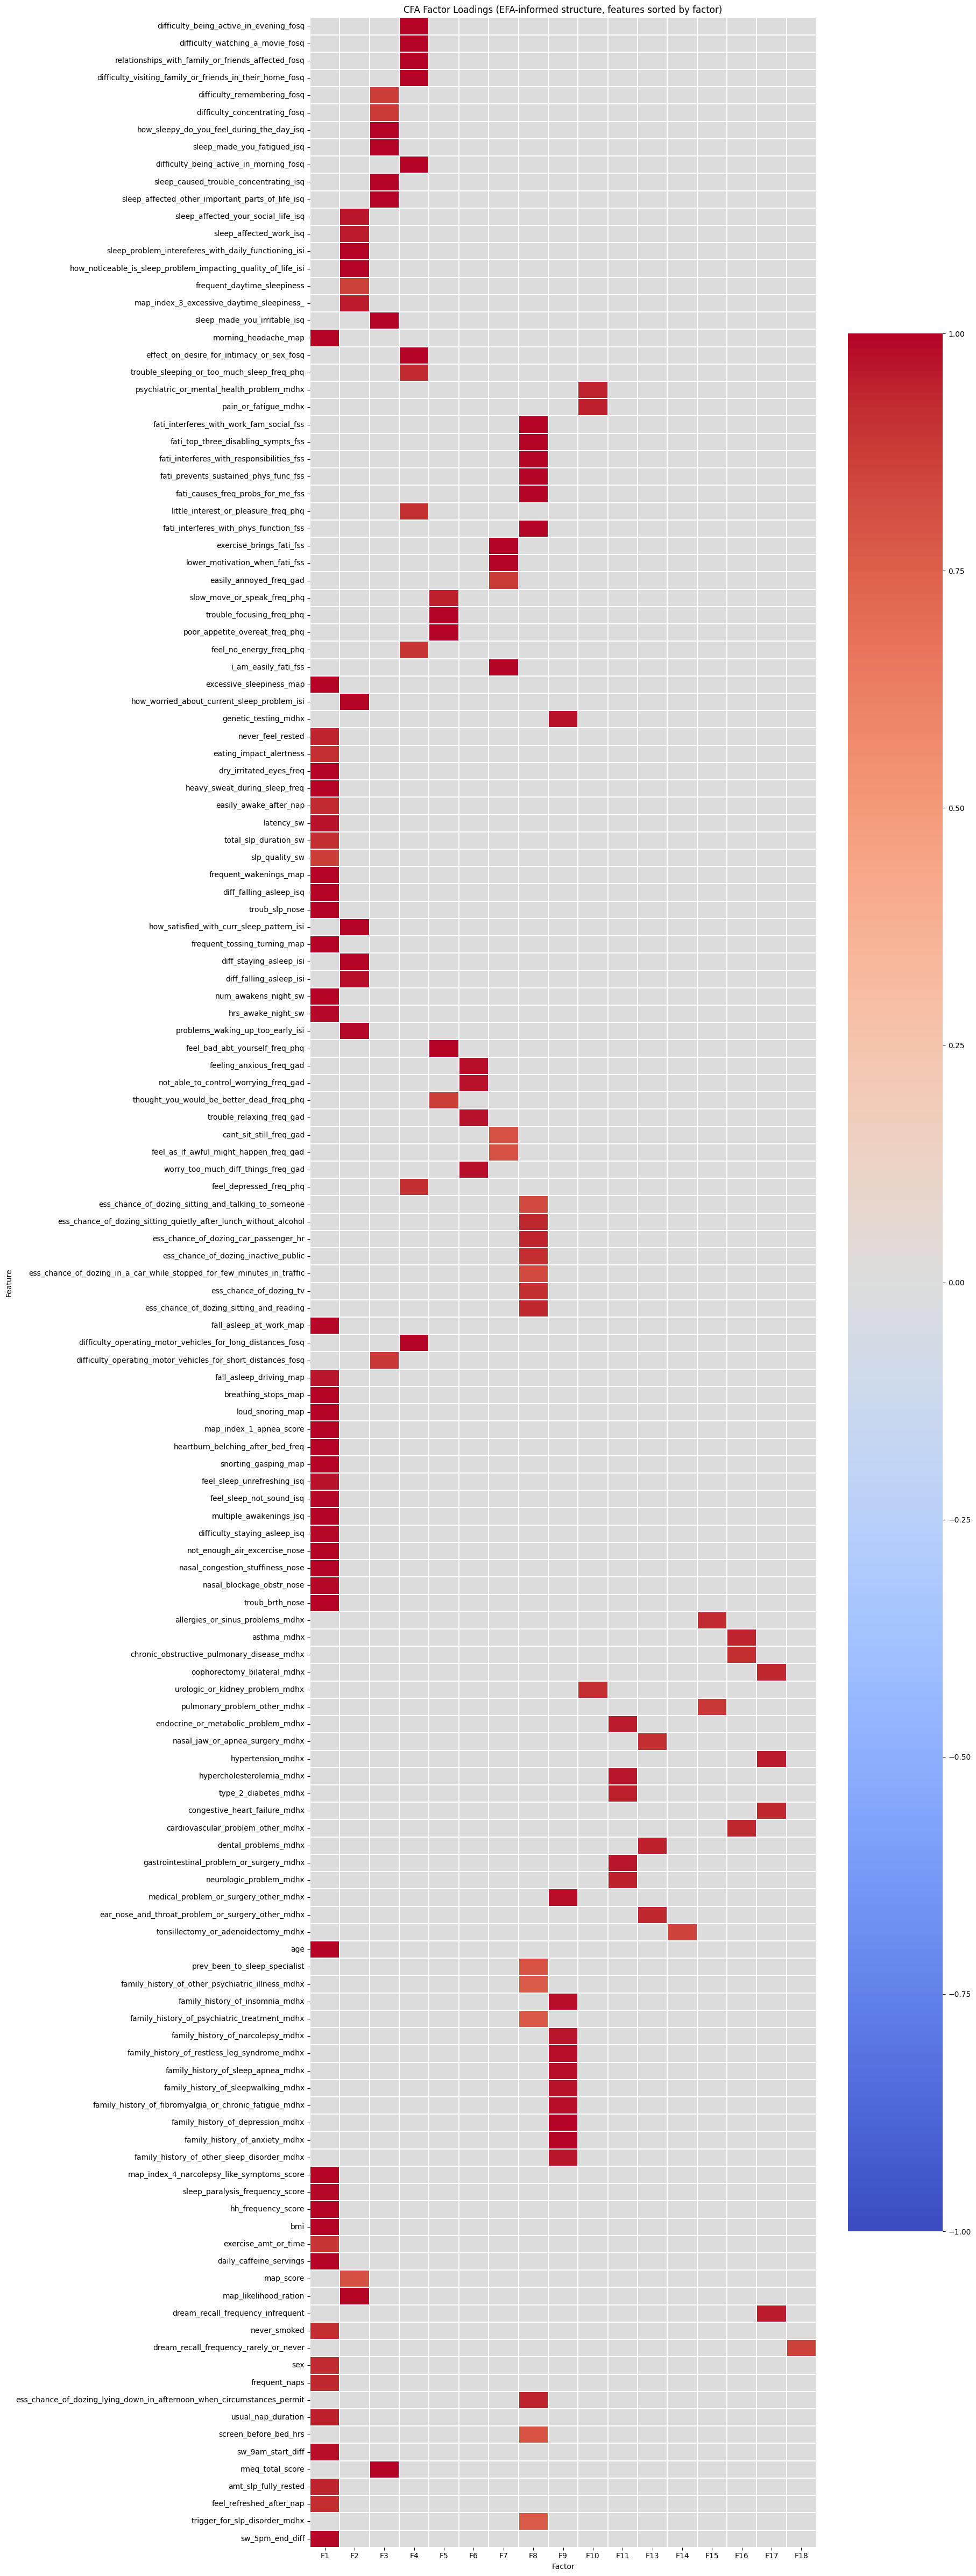

In [8]:
# Sort features by factor assignment for block-diagonal structure
sort_order = factor_assignments.map({col: i for i, col in enumerate(fa_loadings.columns)})
sorted_features = sort_order.sort_values().index
cfa_loadings_sorted = cfa_loadings.loc[sorted_features]

fig, ax = plt.subplots(figsize=(18, max(10, len(encoded_features.columns) // 3)))
sns.heatmap(
    cfa_loadings_sorted,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    ax=ax,
)
ax.set_title("CFA Factor Loadings (EFA-informed structure, features sorted by factor)")
ax.set_xlabel("Factor")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


In [9]:
cfa_scores = confirmatory_factor_analyzer.transform(encoded_features.values)
cfa_df = pd.DataFrame(cfa_scores, columns=list(model_dict.keys()))
cfa_df["ahi"] = encoded_target.values

cfa_dataset_path = "../../data/processed/mlflow/mlflow_cfa_dataset_v1.csv"
cfa_df.to_csv(cfa_dataset_path, index=False)

print(f"CFA dataset saved to {cfa_dataset_path}  shape={cfa_df.shape}")
display(cfa_df.head(5))


CFA dataset saved to ../../data/processed/mlflow/mlflow_cfa_dataset_v1.csv  shape=(1687, 18)


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F13,F14,F15,F16,F17,F18,ahi
0,-0.143716,-0.104106,0.082198,0.310315,-0.156887,-0.066842,-0.168565,-0.124902,-0.185536,-0.300405,-0.205800,-0.244269,-0.292704,-0.238758,-0.132812,-0.165508,0.585288,0.3
1,-0.496754,0.223433,0.453341,-0.981626,-0.343780,-0.590463,0.490244,0.563383,0.357905,0.770250,-0.205800,-0.244269,-0.292704,-0.238758,-0.132812,0.076625,-0.570896,0.4
2,-0.100753,0.981688,0.921126,-0.245896,-0.136531,-0.100637,0.183422,-0.311052,-0.185536,-0.300405,-0.205800,0.461106,0.874651,-0.238758,-0.132812,-0.165508,0.585288,1.0
3,0.053249,-0.516036,-0.086786,-0.100491,0.311715,1.176224,-0.446000,-0.995069,-0.004060,0.410342,-0.006082,-0.244269,-0.292704,-0.238758,-0.132812,-0.165508,0.585288,3.9
4,-0.495538,-0.405588,0.519192,-0.272442,0.051571,0.196574,0.180937,-0.330084,0.169108,0.053340,-0.205800,0.100875,-0.292704,0.310243,-0.132812,0.079199,0.585288,1.3


## **Feature Importances: EFA & CFA Datasets**

Compare feature importance and permutation importance across the EFA factor dataset, CFA factor dataset, and the original encoded features. A helper function handles permutation importance computation and visualisation. Concludes with a top-N feature selection step that produces reduced datasets used in the MLflow comparison experiments.


### EFA Dataset Feature Importances

In [11]:
# get feature importances from efa and cfa datasets
rf_model = RandomForestClassifier(n_estimators=500, random_state=42)

fa_X = fa_df.drop(columns=["ahi"])
fa_y = fa_df["ahi"]
fa_y = convert_ahi(fa_y, threshold=15)

fa_X_train, fa_test_X, fa_train_y, fa_test_y = train_test_split(fa_X, fa_y, test_size=0.2, random_state=42)
rf_model.fit(fa_X_train, fa_train_y)
fa_importances = pd.Series(rf_model.feature_importances_, index=fa_X.columns).sort_values(ascending=False)

display(fa_importances)

Factor_1     0.071794
Factor_12    0.064804
Factor_6     0.063199
Factor_13    0.059278
Factor_14    0.058901
Factor_3     0.056448
Factor_17    0.053780
Factor_7     0.053722
Factor_16    0.053469
Factor_5     0.052946
Factor_15    0.052577
Factor_9     0.052011
Factor_4     0.051783
Factor_2     0.051735
Factor_10    0.051502
Factor_8     0.050967
Factor_11    0.050896
Factor_18    0.050187
dtype: float64

Elapsed time to compute the importances: 4.688 seconds


Factor_10    0.004882
Factor_7     0.003994
Factor_9     0.002071
Factor_16    0.000592
Factor_14   -0.003254
Factor_13   -0.003698
Factor_18   -0.003994
Factor_12   -0.004586
Factor_4    -0.004734
Factor_11   -0.004882
Factor_2    -0.005178
Factor_17   -0.006065
Factor_1    -0.007249
Factor_15   -0.007544
Factor_5    -0.007988
Factor_8    -0.008728
Factor_3    -0.008876
Factor_6    -0.011686
dtype: float64

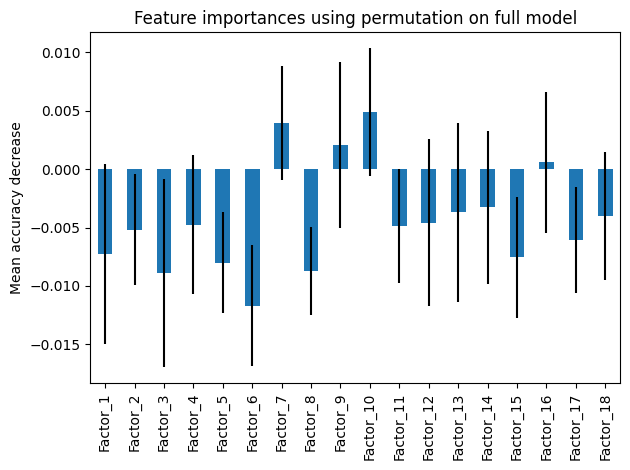

In [ ]:
plot_permutation_importance(rf_model, fa_test_X, fa_test_y)


In [13]:
# look at top loadings for factors 7, 9, 10, 16
# fa_loadings columns are 0-indexed ints, so Factor_N = index N-1
columns_of_interest = [6, 8, 9, 15]
fa_loadings_subset = fa_loadings[columns_of_interest]

n = 7
top_features = {}
for factor in fa_loadings_subset.columns:
    top = fa_loadings_subset[factor].abs().nlargest(n)
    top_features[f"Factor_{factor+1}"] = [f"{feat}  ({fa_loadings_subset.loc[feat, factor]:+.2f})" for feat in top.index]

pd.DataFrame(top_features, index=[f"#{i+1}" for i in range(n)])

,Factor_7,Factor_9,Factor_10,Factor_16
#1,troub_brth_nose (+0.84),family_history_of_psychiatric_treatment_mdhx ...,map_index_4_narcolepsy_like_symptoms_score (+...,latency_sw (+0.42)
#2,nasal_blockage_obstr_nose (+0.80),family_history_of_depression_mdhx (+0.64),hh_frequency_score (+0.73),diff_falling_asleep_isi (+0.34)
#3,nasal_congestion_stuffiness_nose (+0.74),family_history_of_anxiety_mdhx (+0.58),sleep_paralysis_frequency_score (+0.67),diff_falling_asleep_isq (+0.33)
#4,not_enough_air_excercise_nose (+0.62),family_history_of_other_psychiatric_illness_md...,fall_asleep_driving_map (+0.28),how_satisfied_with_curr_sleep_pattern_isi (-0...
#5,allergies_or_sinus_problems_mdhx (+0.42),family_history_of_insomnia_mdhx (+0.32),map_index_3_excessive_daytime_sleepiness_ (+0...,sex (+0.21)
#6,ear_nose_and_throat_problem_or_surgery_other_m...,family_history_of_fibromyalgia_or_chronic_fati...,morning_headache_map (+0.24),rmeq_total_score (-0.20)
#7,asthma_mdhx (+0.19),psychiatric_or_mental_health_problem_mdhx (+0...,fall_asleep_at_work_map (+0.18),sleep_problem_intereferes_with_daily_functioni...


### CFA Dataset Feature Importances

In [14]:
cfa_X = cfa_df.drop(columns=["ahi"])
cfa_y = cfa_df["ahi"]
cfa_y = convert_ahi(cfa_y, threshold=15)
cfa_X_train, cfa_test_X, cfa_train_y, cfa_test_y = train_test_split(cfa_X, cfa_y, test_size=0.2, random_state=42)
rf_model.fit(cfa_X_train, cfa_train_y)
cfa_importances = pd.Series(rf_model.feature_importances_, index=cfa_X.columns).sort_values(ascending=False)
display(cfa_importances)

F1     0.122963
F2     0.106314
F3     0.101586
F8     0.094358
F7     0.083305
F4     0.082814
F9     0.072517
F5     0.060466
F6     0.060063
F11    0.049931
F17    0.032628
F10    0.032281
F13    0.031367
F16    0.025472
F15    0.018228
F14    0.013250
F18    0.012455
dtype: float64

/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Elapsed time to compute the importances: 4.337 seconds


F1     0.017160
F8     0.016420
F2     0.012870
F10    0.006065
F9     0.005178
F4     0.005030
F11    0.004882
F3     0.004734
F6     0.003402
F17    0.003254
F13    0.002367
F14    0.002219
F15    0.001775
F5     0.001183
F16   -0.000888
F7    -0.001331
F18   -0.002219
dtype: float64

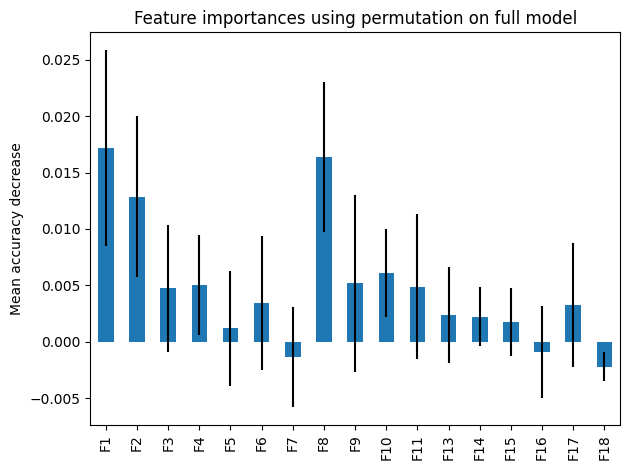

In [ ]:
plot_permutation_importance(rf_model, cfa_test_X, cfa_test_y)


In [16]:
# show features that are important from cfa data

n = 7
top_features = {}
for factor in cfa_loadings.columns:
    top = cfa_loadings[factor].abs().nlargest(n)
    top_features[factor] = [f"{feat}  ({cfa_loadings.loc[feat, factor]:+.2f})" for feat in top.index]

pd.DataFrame(top_features, index=[f"#{i+1}" for i in range(n)])

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F13,F14,F15,F16,F17,F18
#1,bmi (+1.11),how_noticeable_is_sleep_problem_impacting_qual...,rmeq_total_score (+1.07),difficulty_being_active_in_evening_fosq (+1.03),trouble_focusing_freq_phq (+1.00),worry_too_much_diff_things_freq_gad (+0.98),i_am_easily_fati_fss (+1.21),fati_interferes_with_work_fam_social_fss (+1.26),family_history_of_depression_mdhx (+0.99),pain_or_fatigue_mdhx (+0.95),gastrointestinal_problem_or_surgery_mdhx (+0.97),dental_problems_mdhx (+0.95),tonsillectomy_or_adenoidectomy_mdhx (+0.86),allergies_or_sinus_problems_mdhx (+0.93),asthma_mdhx (+0.94),hypertension_mdhx (+0.96),dream_recall_frequency_rarely_or_never (+0.86)
#2,age (+1.09),map_likelihood_ration (+1.07),sleep_made_you_irritable_isq (+1.03),difficulty_watching_a_movie_fosq (+1.03),poor_appetite_overeat_freq_phq (+1.00),feeling_anxious_freq_gad (+0.98),lower_motivation_when_fati_fss (+1.13),fati_top_three_disabling_sympts_fss (+1.26),family_history_of_anxiety_mdhx (+0.99),psychiatric_or_mental_health_problem_mdhx (+0...,hypercholesterolemia_mdhx (+0.96),ear_nose_and_throat_problem_or_surgery_other_m...,age (+0.00),pulmonary_problem_other_mdhx (+0.88),cardiovascular_problem_other_mdhx (+0.93),dream_recall_frequency_infrequent (+0.95),age (+0.00)
#3,breathing_stops_map (+1.08),sleep_problem_intereferes_with_daily_functioni...,sleep_made_you_fatigued_isq (+1.02),effect_on_desire_for_intimacy_or_sex_fosq (+1...,feel_bad_abt_yourself_freq_phq (+1.00),not_able_to_control_worrying_freq_gad (+0.97),exercise_brings_fati_fss (+1.07),fati_causes_freq_probs_for_me_fss (+1.25),family_history_of_sleep_apnea_mdhx (+0.98),urologic_or_kidney_problem_mdhx (+0.91),endocrine_or_metabolic_problem_mdhx (+0.96),nasal_jaw_or_apnea_surgery_mdhx (+0.92),bmi (+0.00),age (+0.00),chronic_obstructive_pulmonary_disease_mdhx (+...,oophorectomy_bilateral_mdhx (+0.94),bmi (+0.00)
#4,snorting_gasping_map (+1.08),how_worried_about_current_sleep_problem_isi (...,sleep_affected_other_important_parts_of_life_i...,difficulty_being_active_in_morning_fosq (+1.02),slow_move_or_speak_freq_phq (+0.95),trouble_relaxing_freq_gad (+0.97),easily_annoyed_freq_gad (+0.88),fati_interferes_with_responsibilities_fss (+1...,family_history_of_insomnia_mdhx (+0.98),age (+0.00),type_2_diabetes_mdhx (+0.95),age (+0.00),sex (+0.00),bmi (+0.00),age (+0.00),congestive_heart_failure_mdhx (+0.93),sex (+0.00)
#5,frequent_tossing_turning_map (+1.07),how_satisfied_with_curr_sleep_pattern_isi (+1...,sleep_caused_trouble_concentrating_isq (+1.02),relationships_with_family_or_friends_affected_...,thought_you_would_be_better_dead_freq_phq (+0...,age (+0.00),cant_sit_still_freq_gad (+0.80),fati_interferes_with_phys_function_fss (+1.23),medical_problem_or_surgery_other_mdhx (+0.98),bmi (+0.00),neurologic_problem_mdhx (+0.95),bmi (+0.00),sw_9am_start_diff (+0.00),sex (+0.00),bmi (+0.00),age (+0.00),sw_9am_start_diff (+0.00)
#6,map_index_1_apnea_score (+1.07),diff_staying_asleep_isi (+1.02),how_sleepy_do_you_feel_during_the_day_isq (+1...,difficulty_visiting_family_or_friends_in_their...,age (+0.00),bmi (+0.00),feel_as_if_awful_might_happen_freq_gad (+0.80),fati_prevents_sustained_phys_func_fss (+1.23),family_history_of_fibromyalgia_or_chronic_fati...,sex (+0.00),age (+0.00),sex (+0.00),sw_5pm_end_diff (+0.00),sw_9am_start_diff (+0.00),sex (+0.00),bmi (+0.00),sw_5pm_end_diff (+0.00)
#7,frequent_wakenings_map (+1.07),problems_waking_up_too_early_isi (+0.99),difficulty_operating_motor_vehicles_for_short_...,difficulty_operating_motor_vehicles_for_long_d...,bmi (+0.00),sex (+0.00),age (+0.00),ess_chance_of_dozing_car_passenger_hr (+0.94),family_history_of_restless_leg_syndrome_mdhx ...,sw_9am_start_diff (+0.00),bmi (+0.00),sw_9am_start_diff (+0.00),nasal_congestion_stuffiness_nose (+0.00),sw_5pm_end_diff (+0.00),sw_9am_start_diff (+0.00),sex (+0.00),nasal_congestion_stuffiness_nose (+0.00)


### Top Feature Dataset Creation

Select the top-N features by absolute factor loading magnitude from both EFA and CFA results. These reduced datasets are saved to CSV and used as additional inputs in the MLflow comparison experiment.


In [17]:

top_n = 5  # top features per factor

fa_top_features  = list({f for col in fa_loadings.columns  for f in fa_loadings[col].abs().nlargest(top_n).index})
cfa_top_features = list({f for col in cfa_loadings.columns for f in cfa_loadings[col].abs().nlargest(top_n).index})

fa_top_df  = encoded_features[fa_top_features].assign(ahi=encoded_target.values)
cfa_top_df = encoded_features[cfa_top_features].assign(ahi=encoded_target.values)

print(f"EFA top df: {fa_top_df.shape}  ({len(fa_top_features)} unique features)")
print(f"CFA top df: {cfa_top_df.shape}  ({len(cfa_top_features)} unique features)")
display(fa_top_df.head())


EFA top df: (1687, 79)  (78 unique features)
CFA top df: (1687, 69)  (68 unique features)


,feel_as_if_awful_might_happen_freq_gad,map_likelihood_ration,difficulty_operating_motor_vehicles_for_short_distances_fosq,feel_sleep_not_sound_isq,fall_asleep_driving_map,cardiovascular_problem_other_mdhx,family_history_of_psychiatric_treatment_mdhx,sleep_caused_trouble_concentrating_isq,troub_brth_nose,fati_interferes_with_work_fam_social_fss,...,dream_recall_frequency_infrequent,frequent_naps,map_index_3_excessive_daytime_sleepiness_,never_smoked,worry_too_much_diff_things_freq_gad,bmi,diff_staying_asleep_isi,effect_on_desire_for_intimacy_or_sex_fosq,age,ahi
0,0.0,0.959701,4.0,4.0,0.0,0.0,0,2.0,0.0,3.0,...,0.0,0.0,1.000000,0.0,1.0,30.7,2.0,4.0,58.0,0.3
1,0.0,0.105484,3.0,0.0,0.0,0.0,1,4.0,0.0,6.0,...,1.0,0.0,1.000000,1.0,0.0,29.4,0.0,2.0,30.0,0.4
2,0.0,0.050057,4.0,4.0,0.0,0.0,0,4.0,0.0,4.0,...,0.0,0.0,1.333330,1.0,0.0,25.8,4.0,3.0,30.0,1.0
3,0.0,0.447595,4.0,4.0,0.0,0.0,0,1.0,0.0,1.0,...,0.0,0.0,0.666667,0.0,1.0,26.8,1.0,4.0,42.0,3.9
4,0.0,5.142808,4.0,1.0,0.0,0.0,1,3.0,1.0,3.0,...,0.0,0.0,0.333333,0.0,1.0,45.2,2.0,2.0,36.0,1.3


In [18]:
fa_top_df.to_csv("../../data/processed/mlflow/mlflow_fa_top_features_dataset_v1.csv", index=False)
cfa_top_df.to_csv("../../data/processed/mlflow/mlflow_cfa_top_features_dataset_v1.csv", index=False)

## **MLFlow Integrations**

Register all five datasets with MLflow and run a grid of (dataset × model) experiments — RF and HGB — across the encoded baseline, EFA factors, CFA factors, EFA top features, and CFA top features. Metrics (accuracy, AUC, F1, AUPRC), SHAP feature importances, and confusion matrices are logged as artifacts per run.


In [ ]:
mlflow.set_tracking_uri(os.path.abspath("../../mlruns"))

_ds_specs = [
    ("encoded_dataset_v1",          encoded_df,  "../../data/processed/mlflow/mlflow_dataset_v1.csv"),
    ("fa_dataset_v1",               fa_df,       "../../data/processed/mlflow/mlflow_factor_dataset_v1.csv"),
    ("cfa_dataset_v1",              cfa_df,      "../../data/processed/mlflow/mlflow_cfa_dataset_v1.csv"),
    ("fa_top_features_dataset_v1",  fa_top_df,   "../../data/processed/mlflow/mlflow_fa_top_features_dataset_v1.csv"),
    ("cfa_top_features_dataset_v1", cfa_top_df,  "../../data/processed/mlflow/mlflow_cfa_top_features_dataset_v1.csv"),
]

enc_dataset, fa_dataset, cfa_dataset, fa_top_dataset, cfa_top_dataset = [
    mlflow.data.from_pandas(df, source=path, name=name, targets="ahi")
    for name, df, path in _ds_specs
]


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource s

In [ ]:
enc_X = encoded_df.drop(columns=["ahi"])
enc_y = convert_ahi(encoded_df["ahi"], threshold=15)
enc_X_train, enc_test_X, enc_train_y, enc_test_y = train_test_split(enc_X, enc_y, test_size=0.2, random_state=42, stratify=enc_y)

fa_top_X = fa_top_df.drop(columns=["ahi"])
fa_top_y = convert_ahi(fa_top_df["ahi"], threshold=15)
fa_top_X_train, fa_top_test_X, fa_top_train_y, fa_top_test_y = train_test_split(fa_top_X, fa_top_y, test_size=0.2, random_state=42, stratify=fa_top_y)

cfa_top_X = cfa_top_df.drop(columns=["ahi"])
cfa_top_y = convert_ahi(cfa_top_df["ahi"], threshold=15)
cfa_top_X_train, cfa_top_test_X, cfa_top_train_y, cfa_top_test_y = train_test_split(cfa_top_X, cfa_top_y, test_size=0.2, random_state=42, stratify=cfa_top_y)

trials = [
    ("encoded_baseline",  enc_dataset,     enc_X_train,     enc_test_X,     enc_train_y,     enc_test_y),
    ("efa_factors",       fa_dataset,      fa_X_train,      fa_test_X,      fa_train_y,      fa_test_y),
    ("cfa_factors",       cfa_dataset,     cfa_X_train,     cfa_test_X,     cfa_train_y,     cfa_test_y),
    ("efa_top_features",  fa_top_dataset,  fa_top_X_train,  fa_top_test_X,  fa_top_train_y,  fa_top_test_y),
    ("cfa_top_features",  cfa_top_dataset, cfa_top_X_train, cfa_top_test_X, cfa_top_train_y, cfa_top_test_y),
]

model_configs = {
    "rf": (RandomForestClassifier, dict(
        n_estimators=500, max_depth=10, min_samples_leaf=5,
        class_weight="balanced_subsample", random_state=42, n_jobs=-1,
    )),
    "hgb": (HistGradientBoostingClassifier, dict(
        max_iter=1000, learning_rate=0.05, max_depth=4,
        min_samples_leaf=20, class_weight="balanced", random_state=42,
    )),
}

experiment = _setup_experiment("dataset-comparison-v1", {
    "description": "Compare encoded baseline vs EFA/CFA factor datasets across RF and HGB models",
})
_run_mlflow_trials(trials, model_configs)


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


encoded_baseline           rf       0.642   0.590   0.309   0.444         146
encoded_baseline           hgb      0.618   0.552   0.358   0.410         146
efa_factors                rf       0.497   0.485   0.370   0.316          18
efa_factors                hgb      0.521   0.507   0.413   0.330          18
cfa_factors                rf       0.609   0.512   0.205   0.333          17
cfa_factors                hgb      0.604   0.528   0.380   0.376          17


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


efa_top_features           rf       0.624   0.572   0.282   0.422          78
efa_top_features           hgb      0.583   0.563   0.319   0.373          78


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


cfa_top_features           rf       0.624   0.570   0.298   0.426          68
cfa_top_features           hgb      0.565   0.525   0.323   0.355          68


## **SMOTETomek Resampled Dataset Comparison**

Apply SMOTETomek to each dataset's **training split only** to address class imbalance.  
Test sets are kept identical to the baseline experiment for a fair AUPRC comparison.

In [21]:
from imblearn.combine import SMOTETomek

smotetomek = SMOTETomek(random_state=42)

# ── apply resampling to each training split; test sets are unchanged ──────────
smote_trials = []
print(f"{'dataset':<25}  {'before':>8}  {'after':>8}  {'pos_before':>12}  {'pos_after':>10}")
print("-" * 70)
for name, mlflow_ds, X_train, X_test, y_train, y_test in trials:
    X_res, y_res = smotetomek.fit_resample(X_train, y_train)
    # preserve DataFrame column names lost during resampling
    X_res = pd.DataFrame(X_res, columns=X_train.columns)
    y_res = pd.Series(y_res, name=y_train.name)
    smote_trials.append((name, mlflow_ds, X_res, X_test, y_res, y_test))
    print(f"{name:<25}  {len(y_train):>8}  {len(y_res):>8}  {int(y_train.sum()):>12}  {int(y_res.sum()):>10}")

dataset                      before     after    pos_before   pos_after
----------------------------------------------------------------------
encoded_baseline               1349      1732           461         866
efa_factors                    1349      1252           464         626
cfa_factors                    1349      1684           464         842
efa_top_features               1349      1728           461         864
cfa_top_features               1349      1730           461         865


In [ ]:
model_configs_balanced = {
    "rf": (RandomForestClassifier, dict(
        n_estimators=500, max_depth=10, min_samples_leaf=2,
        random_state=42, n_jobs=-1,
    )),
    "hgb": (HistGradientBoostingClassifier, dict(
        max_iter=1000, learning_rate=0.05, max_depth=4,
        min_samples_leaf=10, random_state=42,
    )),
}

experiment_smote = _setup_experiment("dataset-comparison-smotetomek-v1", {
    "description": "Same datasets as dataset-comparison-v1 with SMOTETomek resampling on training splits",
    "resampling": "SMOTETomek",
})
_run_mlflow_trials(smote_trials, model_configs_balanced, extra_run_tags={"resampling": "SMOTETomek"})


dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------
encoded_baseline           rf       0.642   0.574   0.219   0.402         146
encoded_baseline           hgb      0.633   0.576   0.295   0.430         146
efa_factors                rf       0.485   0.463   0.370   0.302          18
efa_factors                hgb      0.521   0.494   0.367   0.315          18
cfa_factors                rf       0.609   0.502   0.175   0.333          17
cfa_factors                hgb      0.595   0.488   0.283   0.333          17
efa_top_features           rf       0.630   0.596   0.204   0.414          78
efa_top_features           hgb      0.651   0.596   0.344   0.415          78
cfa_top_features           rf       0.621   0.558   0.220   0.409          68
cfa_top_features           hgb      0.586   0.525   0.271   0.352          68


# Feature Selection Reprocessing:

## IRT-Based Dataset

Replace each validated Likert-scale questionnaire with a single **IRT theta score** estimated via the **Graded Response Model (GRM)**. Theta is an information-weighted latent trait estimate — it accounts for each item's discrimination and threshold difficulty, unlike raw sum scores which weight all items equally.

GRM parameters are estimated per scale using marginal maximum likelihood (`grm_mml`). Person thetas are recovered with EAP (Expected A Posteriori) scoring using a N(0,1) prior.

| Feature | Scale | Items | Response categories |
|---|---|---|---|
| `theta_depression` | PHQ-9 | 9 | 0–3 |
| `theta_anxiety` | GAD-7 | 7 | 0–3 |
| `theta_fatigue` | FSS-9 | 9 | 1–7 (shifted to 0–6) |
| `theta_nasal_obstruction` | NOSE | 5 | 0–4 |
| `theta_osa_symptoms` | OSA items | 3 | 0–5 |

In [ ]:
from girth import grm_mml

# ── scale definitions ─────────────────────────────────────────────────────────
IRT_SCALES = {
    "theta_depression":        [c for c in encoded_df.columns if c.endswith("_phq")],
    "theta_anxiety":           [c for c in encoded_df.columns if c.endswith("_gad")],
    "theta_fatigue":           [c for c in encoded_df.columns if c.endswith("_fss")],
    "theta_nasal_obstruction": [c for c in encoded_df.columns if c.endswith("_nose")],
    "theta_osa_symptoms":      [
        "heartburn_belching_after_bed_freq",
        "heavy_sweat_during_sleep_freq",
        "dry_irritated_eyes_freq",
    ],
}

all_scale_cols = [col for cols in IRT_SCALES.values() for col in cols]

# ── fit GRM per scale and score respondents ───────────────────────────────────
theta_scores = {}
print(f"{'scale':<30}  {'items':>5}  {'theta min':>10}  {'theta max':>10}")
print("-" * 60)
for theta_name, item_cols in IRT_SCALES.items():
    items = encoded_df[item_cols].values.astype(int)
    items = items - items.min()      # shift to 0-indexed (handles FSS 1–7 → 0–6)
    data_T = items.T                 # (n_items, n_persons)

    grm_params = grm_mml(data_T)
    theta = grm_score_eap(data_T, grm_params["Discrimination"], grm_params["Difficulty"])
    theta_scores[theta_name] = theta
    print(f"{theta_name:<30}  {len(item_cols):>5}  {theta.min():>10.3f}  {theta.max():>10.3f}")

# ── build IRT dataset: drop item columns, insert theta scores before ahi ──────
irt_df = encoded_df.drop(columns=all_scale_cols).copy()
ahi_loc = irt_df.columns.get_loc("ahi")
for theta_name, scores in theta_scores.items():
    irt_df.insert(ahi_loc, theta_name, scores)
    ahi_loc += 1   # keep new columns before ahi

irt_dataset_path = "../../data/processed/mlflow/mlflow_irt_dataset_v1.csv"
irt_df.to_csv(irt_dataset_path, index=False)

print(f"\nIRT dataset saved → {irt_dataset_path}")
print(f"Shape: {irt_df.shape}  (dropped {len(all_scale_cols)} item cols, added {len(IRT_SCALES)} theta cols)")
display(irt_df.head())


scale                           items   theta min   theta max
------------------------------------------------------------
theta_depression                    9      -1.587       3.006
theta_anxiety                       7      -1.261       2.615
theta_fatigue                       9      -2.024       2.189
theta_nasal_obstruction             5      -1.231       2.858


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/girth/unidimensional/polytomous/grm_mml.py:156: RuntimeWarning: invalid value encountered in log
  return -np.log(otpt).sum()
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/girth/unidimensional/polytomous/grm_mml.py:156: RuntimeWarning: invalid value encountered in log
  return -np.log(otpt).sum()


theta_osa_symptoms                  3      -1.043       2.928

IRT dataset saved → ../../data/processed/mlflow/mlflow_irt_dataset_v1.csv
Shape: (1687, 119)  (dropped 33 item cols, added 5 theta cols)


,age,bmi,sex,sw_9am_start_diff,sw_5pm_end_diff,exercise_amt_or_time,daily_caffeine_servings,eating_impact_alertness,never_smoked,never_feel_rested,...,hypertension_mdhx,oophorectomy_bilateral_mdhx,theta_depression,theta_anxiety,theta_fatigue,theta_nasal_obstruction,theta_osa_symptoms,ahi,dream_recall_frequency_infrequent,dream_recall_frequency_rarely_or_never
0,58.0,30.7,1.0,-1.00,0.0,1.0,2.0,2.0,0.0,0.0,...,0.0,0.0,-0.324279,0.083694,-0.040206,-0.418735,-0.013245,0.3,0.0,1.0
1,30.0,29.4,1.0,-1.00,0.0,1.0,3.0,2.0,1.0,1.0,...,0.0,0.0,0.567647,-0.458682,0.956447,-1.102886,0.726906,0.4,1.0,0.0
2,30.0,25.8,1.0,-2.00,2.0,1.0,1.0,2.0,1.0,0.0,...,0.0,0.0,-0.956219,-0.024499,0.170148,-0.897600,0.250793,1.0,0.0,1.0
3,42.0,26.8,0.0,-3.00,3.0,1.0,3.0,2.0,0.0,1.0,...,0.0,0.0,-0.264815,0.994030,-1.664292,-0.376366,0.066692,3.9,0.0,1.0
4,36.0,45.2,0.0,-0.75,0.5,0.0,2.0,2.0,0.0,0.0,...,1.0,0.0,0.119183,0.499408,-0.356772,0.615183,-1.043423,1.3,0.0,1.0


In [ ]:
irt_mlflow_ds = mlflow.data.from_pandas(
    irt_df, source=irt_dataset_path, name="irt_dataset_v1", targets="ahi"
)

irt_X = irt_df.drop(columns=["ahi"])
irt_y = convert_ahi(irt_df["ahi"], threshold=15)
irt_X_train, irt_test_X, irt_train_y, irt_test_y = train_test_split(
    irt_X, irt_y, test_size=0.2, random_state=42, stratify=irt_y
)

irt_trials = [
    ("encoded_baseline", enc_dataset,   enc_X_train,  enc_test_X,  enc_train_y,  enc_test_y),
    ("irt_dataset_v1",   irt_mlflow_ds, irt_X_train,  irt_test_X,  irt_train_y,  irt_test_y),
]

experiment_irt = _setup_experiment("dataset-comparison-irt-v1", {
    "description": "IRT-scored dataset vs encoded baseline — RF and HGB",
    "feature_engineering": "GRM-EAP",
})
_run_mlflow_trials(irt_trials, model_configs)


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------
encoded_baseline           rf       0.642   0.590   0.309   0.444         146
encoded_baseline           hgb      0.618   0.552   0.358   0.410         146


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


irt_dataset_v1             rf       0.639   0.569   0.282   0.421         118
irt_dataset_v1             hgb      0.586   0.544   0.320   0.379         118


## IRT Hybrid Experiments

Two hybrid variants tested against the encoded baseline and the pure IRT replacement dataset:

- **`irt_augmented`** — all 146 original encoded features *plus* the 5 theta scores (151 features total). Lets the model exploit both raw items and latent traits.
- **`irt_augmented` + SMOTETomek** — same augmented dataset with SMOTETomek oversampling on the training split only, using the balanced model configs.

In [ ]:
irt_aug_df = encoded_df.copy()
for theta_name, scores in theta_scores.items():
    irt_aug_df[theta_name] = scores

irt_aug_path = "../../data/processed/mlflow/mlflow_irt_augmented_dataset_v1.csv"
irt_aug_df.to_csv(irt_aug_path, index=False)
print(f"IRT augmented dataset: {irt_aug_df.shape}  ({encoded_df.shape[1] - 1} original + {len(theta_scores)} theta cols)")

irt_aug_mlflow_ds = mlflow.data.from_pandas(irt_aug_df, source=irt_aug_path, name="irt_augmented_v1", targets="ahi")

irt_aug_X = irt_aug_df.drop(columns=["ahi"])
irt_aug_y = convert_ahi(irt_aug_df["ahi"], threshold=15)
irt_aug_X_train, irt_aug_test_X, irt_aug_train_y, irt_aug_test_y = train_test_split(
    irt_aug_X, irt_aug_y, test_size=0.2, random_state=42, stratify=irt_aug_y
)

hybrid_trials = [
    ("encoded_baseline", enc_dataset,      enc_X_train,     enc_test_X,     enc_train_y,     enc_test_y),
    ("irt_replacement",  irt_mlflow_ds,    irt_X_train,     irt_test_X,     irt_train_y,     irt_test_y),
    ("irt_augmented",    irt_aug_mlflow_ds, irt_aug_X_train, irt_aug_test_X, irt_aug_train_y, irt_aug_test_y),
]

experiment_irt_hybrid = _setup_experiment("dataset-comparison-irt-hybrid-v1", {
    "description": "IRT augmented (items + thetas) vs IRT replacement vs encoded baseline",
    "feature_engineering": "GRM-EAP",
})
_run_mlflow_trials(hybrid_trials, model_configs)


IRT augmented dataset: (1687, 152)  (146 original + 5 theta cols)

dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


encoded_baseline           rf       0.642   0.590   0.309   0.444         146
encoded_baseline           hgb      0.618   0.552   0.358   0.410         146
irt_replacement            rf       0.639   0.569   0.282   0.421         118
irt_replacement            hgb      0.586   0.544   0.320   0.379         118


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


irt_augmented              rf       0.651   0.600   0.289   0.460         151
irt_augmented              hgb      0.612   0.544   0.367   0.395         151


In [ ]:
irt_smote_trials = []
print(f"{'dataset':<25}  {'before':>8}  {'after':>8}  {'pos_before':>12}  {'pos_after':>10}")
print("-" * 70)
for name, mlflow_ds, X_train, X_test, y_train, y_test in hybrid_trials:
    X_res, y_res = smotetomek.fit_resample(X_train, y_train)
    X_res = pd.DataFrame(X_res, columns=X_train.columns)
    y_res = pd.Series(y_res, name=y_train.name)
    irt_smote_trials.append((name, mlflow_ds, X_res, X_test, y_res, y_test))
    print(f"{name:<25}  {len(y_train):>8}  {len(y_res):>8}  {int(y_train.sum()):>12}  {int(y_res.sum()):>10}")

experiment_irt_smote = _setup_experiment("dataset-comparison-irt-smotetomek-v1", {
    "description": "IRT hybrid datasets with SMOTETomek resampling on training splits",
    "feature_engineering": "GRM-EAP",
    "resampling": "SMOTETomek",
})
_run_mlflow_trials(irt_smote_trials, model_configs_balanced, extra_run_tags={"resampling": "SMOTETomek"})


dataset                      before     after    pos_before   pos_after
----------------------------------------------------------------------
encoded_baseline               1349      1732           461         866
irt_replacement                1349      1728           461         864


2026/05/28 12:23:24 INFO mlflow.tracking.fluent: Experiment with name 'dataset-comparison-irt-smotetomek-v1' does not exist. Creating a new experiment.


irt_augmented                  1349      1734           461         867

dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------
encoded_baseline           rf       0.642   0.574   0.219   0.402         146
encoded_baseline           hgb      0.633   0.576   0.295   0.430         146
irt_replacement            rf       0.645   0.558   0.231   0.390         118
irt_replacement            hgb      0.615   0.558   0.261   0.385         118
irt_augmented              rf       0.648   0.567   0.232   0.410         151
irt_augmented              hgb      0.618   0.566   0.295   0.412         151


─── Mean |SHAP| for theta scores (irt_augmented, both models) ───
theta_fatigue              0.111321
theta_anxiety              0.100561
theta_osa_symptoms         0.089104
theta_nasal_obstruction    0.082247
theta_depression           0.049196

Ranks out of 151 features:
theta_fatigue               5
theta_anxiety               8
theta_osa_symptoms         10
theta_nasal_obstruction    12
theta_depression           27


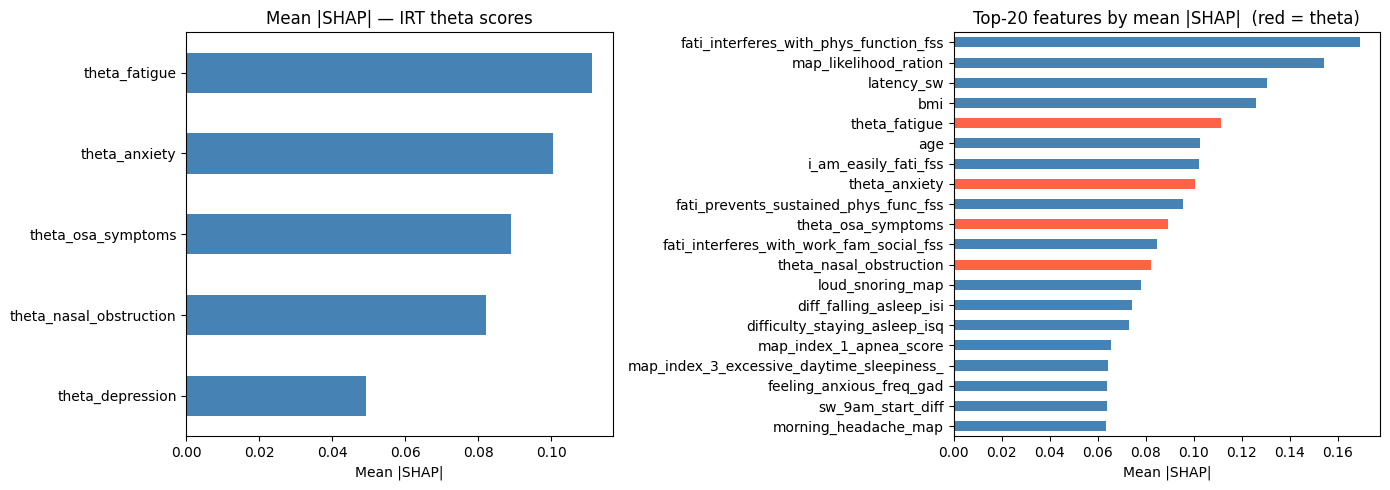

In [34]:
# ── theta SHAP contribution analysis ─────────────────────────────────────────
# Pull SHAP metrics logged for irt_augmented runs from MLflow
theta_cols = list(theta_scores.keys())

runs_df = mlflow.search_runs(
    experiment_ids=[experiment_irt_hybrid.experiment_id],
    filter_string="tags.dataset = 'irt_augmented'",
)

shap_cols = [c for c in runs_df.columns if c.startswith("metrics.shap_")]
shap_summary = runs_df[["tags.model_type"] + shap_cols].copy()
shap_summary.columns = [c.replace("metrics.shap_", "") for c in shap_summary.columns]
shap_summary = shap_summary.rename(columns={"tags.model_type": "model"}).set_index("model")

# Mean SHAP across models for every feature
mean_shap_all = shap_summary.mean(axis=0).sort_values(ascending=False)
theta_shap = mean_shap_all[mean_shap_all.index.isin(theta_cols)].sort_values(ascending=False)

print("─── Mean |SHAP| for theta scores (irt_augmented, both models) ───")
print(theta_shap.to_string())

# Rank of each theta among all 151 features
ranks = mean_shap_all.rank(ascending=False).astype(int)
print(f"\nRanks out of {len(mean_shap_all)} features:")
print(ranks[theta_cols].sort_values().to_string())

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: theta SHAP values
theta_shap.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Mean |SHAP| — IRT theta scores")
axes[0].set_xlabel("Mean |SHAP|")
axes[0].invert_yaxis()

# Right: top-20 features overall with thetas highlighted
top20 = mean_shap_all.head(20)
colors = ["tomato" if f in theta_cols else "steelblue" for f in top20.index]
top20.plot.barh(ax=axes[1], color=colors)
axes[1].set_title("Top-20 features by mean |SHAP|  (red = theta)")
axes[1].set_xlabel("Mean |SHAP|")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## SHAP-Selected Feature Dataset

Build a reduced version of `irt_augmented` by keeping the top-30 features by mean |SHAP| (all 5 theta scores are force-included). This reduces dimensionality from 151 → ~30 features for a ~1350-sample training set, improving the sample-to-feature ratio and reducing noise for the subsequent hyperparameter tuning step.

In [ ]:
TOP_N_SHAP = 30

top_shap_features = mean_shap_all.head(TOP_N_SHAP).index.tolist()
selected_features = list(dict.fromkeys(top_shap_features + theta_cols))

irt_shap_df = irt_aug_df[selected_features + ["ahi"]].copy()
irt_shap_path = "../../data/processed/mlflow/mlflow_irt_shap_selected_v1.csv"
irt_shap_df.to_csv(irt_shap_path, index=False)
print(f"SHAP-selected dataset: {irt_shap_df.shape}  ({len(selected_features)} features)")
print(f"Features: {selected_features}")

irt_shap_mlflow_ds = mlflow.data.from_pandas(irt_shap_df, source=irt_shap_path, name="irt_shap_selected_v1", targets="ahi")

irt_shap_X = irt_shap_df.drop(columns=["ahi"])
irt_shap_y = convert_ahi(irt_shap_df["ahi"], threshold=15)
irt_shap_X_train, irt_shap_test_X, irt_shap_train_y, irt_shap_test_y = train_test_split(
    irt_shap_X, irt_shap_y, test_size=0.2, random_state=42, stratify=irt_shap_y
)

shap_sel_trials = [
    ("irt_augmented_full",       irt_aug_mlflow_ds,  irt_aug_X_train,   irt_aug_test_X,   irt_aug_train_y,   irt_aug_test_y),
    (f"irt_shap_top{TOP_N_SHAP}", irt_shap_mlflow_ds, irt_shap_X_train, irt_shap_test_X, irt_shap_train_y, irt_shap_test_y),
]

experiment_shap_sel = _setup_experiment("dataset-comparison-shap-selected-v1", {
    "description": f"irt_augmented top-{TOP_N_SHAP} SHAP features vs full augmented",
    "feature_selection": f"shap_top_{TOP_N_SHAP}",
})
_run_mlflow_trials(shap_sel_trials, model_configs)


SHAP-selected dataset: (1687, 31)  (30 features)
Features: ['fati_interferes_with_phys_function_fss', 'map_likelihood_ration', 'latency_sw', 'bmi', 'theta_fatigue', 'age', 'i_am_easily_fati_fss', 'theta_anxiety', 'fati_prevents_sustained_phys_func_fss', 'theta_osa_symptoms', 'fati_interferes_with_work_fam_social_fss', 'theta_nasal_obstruction', 'loud_snoring_map', 'diff_falling_asleep_isi', 'difficulty_staying_asleep_isq', 'map_index_1_apnea_score', 'map_index_3_excessive_daytime_sleepiness_', 'feeling_anxious_freq_gad', 'sw_9am_start_diff', 'morning_headache_map', 'rmeq_total_score', 'ess_chance_of_dozing_sitting_quietly_after_lunch_without_alcohol', 'neurologic_problem_mdhx', 'difficulty_watching_a_movie_fosq', 'never_feel_rested', 'difficulty_operating_motor_vehicles_for_long_distances_fosq', 'theta_depression', 'poor_appetite_overeat_freq_phq', 'ess_chance_of_dozing_inactive_public', 'frequent_wakenings_map']

dataset                       model      acc     auc      f1   auprc  n_

/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


irt_augmented_full            rf       0.651   0.600   0.289   0.460         151
irt_augmented_full            hgb      0.612   0.544   0.367   0.395         151
irt_shap_top30                rf       0.645   0.584   0.388   0.447          30
irt_shap_top30                hgb      0.589   0.562   0.398   0.397          30


## Hyperparameter Tuning — RF on SHAP-Selected Dataset

`RandomizedSearchCV` with `StratifiedKFold(5)` on the SHAP-selected `irt_augmented` dataset. Optimises for AUPRC (average precision) — more informative than AUC for this imbalanced problem. Best parameters are then evaluated on the held-out test set and logged to MLflow.

In [38]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "n_estimators":    [200, 300, 500, 750, 1000],
    "max_depth":       [5, 7, 10, 13, None],
    "min_samples_leaf":[2, 5, 10, 20],
    "max_features":    ["sqrt", "log2", 0.3, 0.5],
    "class_weight":    ["balanced", "balanced_subsample"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=60,
    scoring="average_precision",
    cv=cv,
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(irt_shap_X_train, irt_shap_train_y)

print(f"Best CV AUPRC: {search.best_score_:.4f}")
print(f"Best params:   {search.best_params_}")

# ── evaluate best model on held-out test set ──────────────────────────────────
best_rf = search.best_estimator_
y_pred  = best_rf.predict(irt_shap_test_X)
y_prob  = best_rf.predict_proba(irt_shap_test_X)[:, 1]

test_acc   = accuracy_score(irt_shap_test_y, y_pred)
test_auc   = roc_auc_score(irt_shap_test_y, y_prob)
test_f1    = f1_score(irt_shap_test_y, y_pred)
test_auprc = average_precision_score(irt_shap_test_y, y_prob)

print(f"\nTest  acc={test_acc:.3f}  auc={test_auc:.3f}  f1={test_f1:.3f}  auprc={test_auprc:.3f}")

# ── log to MLflow ─────────────────────────────────────────────────────────────
experiment_tuned = mlflow.set_experiment("rf-tuned-shap-selected-v1")
mlflow.set_experiment_tags({
    "notebook": "4fe",
    "description": "RandomizedSearchCV tuned RF on SHAP-selected irt_augmented dataset",
    "task": "binary-classification",
    "target": "ahi>=15",
    "feature_selection": f"shap_top_{TOP_N_SHAP}",
    "tuning": "RandomizedSearchCV_n60_cv5",
})

_client = mlflow.MlflowClient()
for _run in mlflow.search_runs(experiment_ids=[experiment_tuned.experiment_id], output_format="list"):
    _client.delete_run(_run.info.run_id)

with mlflow.start_run(run_name="rf_tuned_shap_selected"):
    mlflow.set_tags({"dataset": f"irt_shap_top{TOP_N_SHAP}", "model_type": "rf", "tuning": "RandomizedSearchCV"})
    mlflow.log_input(irt_shap_mlflow_ds, context="training")
    mlflow.log_params(search.best_params_)
    mlflow.log_param("n_features", irt_shap_X_train.shape[1])
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("n_iter", 60)
    mlflow.log_metric("cv_best_auprc", search.best_score_)
    mlflow.log_metrics({
        "test_accuracy": test_acc,
        "test_roc_auc":  test_auc,
        "test_f1":       test_f1,
        "test_auprc":    test_auprc,
    })

    explainer = shap.TreeExplainer(best_rf)
    shap_vals = explainer(irt_shap_test_X)
    sv = shap_vals[..., 1] if shap_vals.values.ndim == 3 else shap_vals

    mean_shap_tuned = pd.Series(np.abs(sv.values).mean(axis=0), index=irt_shap_test_X.columns)
    mlflow.log_metrics({f"shap_{col}": float(v) for col, v in mean_shap_tuned.items()})

    shap.plots.bar(sv, max_display=15, show=False)
    mlflow.log_figure(plt.gcf(), "shap_bar.png")
    plt.close("all")

    cm_fig, cm_ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(irt_shap_test_y, y_pred, ax=cm_ax, colorbar=False)
    cm_ax.set_title(f"RF tuned — irt_shap_top{TOP_N_SHAP}")
    mlflow.log_figure(cm_fig, "confusion_matrix.png")
    plt.close(cm_fig)

    # CV results summary as a CSV artifact
    cv_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
    mlflow.log_text(cv_results.to_csv(index=False), "cv_results.csv")

print("\nLogged to MLflow experiment: rf-tuned-shap-selected-v1")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV AUPRC: 0.4204
Best params:   {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}

Test  acc=0.604  auc=0.583  f1=0.464  auprc=0.429

Logged to MLflow experiment: rf-tuned-shap-selected-v1


# Return to Factor Analysis

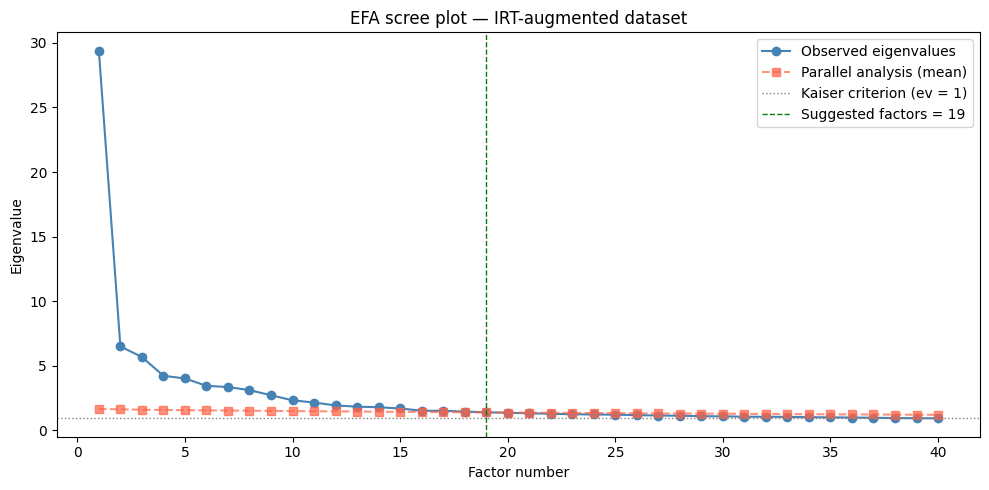

In [ ]:
# efa_elbow_plot imported from src.visualization.plots
efa_elbow_plot(irt_aug_X, max_factors=40)
plt.show()


In [41]:
# factors from dataset

fa_var = FactorAnalyzer(n_factors=19, rotation="varimax")
fa_quartimax = FactorAnalyzer(n_factors=19, rotation="quartimax")
fa_var.fit(irt_aug_X)
fa_quartimax.fit(irt_aug_X)

FactorAnalyzer(n_factors=19, rotation='quartimax', rotation_kwargs={})

In [54]:
_factor_cols = [f"Factor_{i+1}" for i in range(19)]
fa_var_loadings = pd.DataFrame(
    fa_var.loadings_, index=irt_aug_X.columns, columns=_factor_cols
)
fa_quartimax_loadings = pd.DataFrame(
    fa_quartimax.loadings_, index=irt_aug_X.columns, columns=_factor_cols
)

In [57]:
top_n = 5

top_var = {
    f"Varimax_{i+1}": fa_var_loadings[f"Factor_{i+1}"].abs().nlargest(top_n).index.tolist()
    for i in range(19)
}
top_quartimax = {
    f"Quartimax_{i+1}": fa_quartimax_loadings[f"Factor_{i+1}"].abs().nlargest(top_n).index.tolist()
    for i in range(19)
}

print("Top features per factor — Varimax")
display(
    pd.DataFrame(top_var, index=[f"#{i+1}" for i in range(top_n)])
    .style.set_properties(**{"text-align": "left", "white-space": "nowrap"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)

print("\nTop features per factor — Quartimax")
display(
    pd.DataFrame(top_quartimax, index=[f"#{i+1}" for i in range(top_n)])
    .style.set_properties(**{"text-align": "left", "white-space": "nowrap"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)


Top features per factor — Varimax


,Varimax_1,Varimax_2,Varimax_3,Varimax_4,Varimax_5,Varimax_6,Varimax_7,Varimax_8,Varimax_9,Varimax_10,Varimax_11,Varimax_12,Varimax_13,Varimax_14,Varimax_15,Varimax_16,Varimax_17,Varimax_18,Varimax_19
#1,theta_fatigue,theta_anxiety,ess_chance_of_dozing_inactive_public,diff_staying_asleep_isi,theta_nasal_obstruction,sleep_affected_your_social_life_isq,map_index_1_apnea_score,age,family_history_of_depression_mdhx,feel_sleep_not_sound_isq,map_index_4_narcolepsy_like_symptoms_score,theta_osa_symptoms,bmi,rmeq_total_score,dream_recall_frequency_rarely_or_never,sex,latency_sw,ess_chance_of_dozing_lying_down_in_afternoon_when_circumstances_permit,little_interest_or_pleasure_freq_phq
#2,fati_interferes_with_phys_function_fss,not_able_to_control_worrying_freq_gad,ess_chance_of_dozing_sitting_quietly_after_lunch_without_alcohol,troub_slp_nose,troub_brth_nose,sleep_affected_other_important_parts_of_life_isq,snorting_gasping_map,hypercholesterolemia_mdhx,family_history_of_psychiatric_treatment_mdhx,difficulty_staying_asleep_isq,hh_frequency_score,heavy_sweat_during_sleep_freq,map_score,usual_nap_duration,dream_recall_frequency_infrequent,ess_chance_of_dozing_tv,diff_falling_asleep_isi,difficulty_operating_motor_vehicles_for_short_distances_fosq,feel_depressed_freq_phq
#3,fati_causes_freq_probs_for_me_fss,worry_too_much_diff_things_freq_gad,map_index_3_excessive_daytime_sleepiness_,how_satisfied_with_curr_sleep_pattern_isi,nasal_blockage_obstr_nose,sleep_affected_work_isq,breathing_stops_map,medical_problem_or_surgery_other_mdhx,family_history_of_anxiety_mdhx,multiple_awakenings_isq,sleep_paralysis_frequency_score,dry_irritated_eyes_freq,map_likelihood_ration,age,never_smoked,map_score,diff_falling_asleep_isq,frequent_naps,theta_depression
#4,fati_top_three_disabling_sympts_fss,feeling_anxious_freq_gad,ess_chance_of_dozing_in_a_car_while_stopped_for_few_minutes_in_traffic,diff_falling_asleep_isi,nasal_congestion_stuffiness_nose,sleep_caused_trouble_concentrating_isq,loud_snoring_map,hypertension_mdhx,family_history_of_other_psychiatric_illness_mdhx,feel_sleep_unrefreshing_isq,fall_asleep_driving_map,heartburn_belching_after_bed_freq,hypertension_mdhx,map_index_3_excessive_daytime_sleepiness_,frequent_naps,morning_headache_map,how_satisfied_with_curr_sleep_pattern_isi,difficulty_operating_motor_vehicles_for_long_distances_fosq,feel_bad_abt_yourself_freq_phq
#5,fati_prevents_sustained_phys_func_fss,trouble_relaxing_freq_gad,ess_chance_of_dozing_car_passenger_hr,diff_falling_asleep_isq,not_enough_air_excercise_nose,sleep_made_you_irritable_isq,map_score,gastrointestinal_problem_or_surgery_mdhx,family_history_of_insomnia_mdhx,sleep_made_you_fatigued_isq,map_index_3_excessive_daytime_sleepiness_,gastrointestinal_problem_or_surgery_mdhx,exercise_amt_or_time,excessive_sleepiness_map,frequent_daytime_sleepiness,ess_chance_of_dozing_car_passenger_hr,hrs_awake_night_sw,ess_chance_of_dozing_sitting_and_reading,difficulty_visiting_family_or_friends_in_their_home_fosq



Top features per factor — Quartimax


,Quartimax_1,Quartimax_2,Quartimax_3,Quartimax_4,Quartimax_5,Quartimax_6,Quartimax_7,Quartimax_8,Quartimax_9,Quartimax_10,Quartimax_11,Quartimax_12,Quartimax_13,Quartimax_14,Quartimax_15,Quartimax_16,Quartimax_17,Quartimax_18,Quartimax_19
#1,theta_fatigue,theta_anxiety,diff_staying_asleep_isi,ess_chance_of_dozing_inactive_public,theta_nasal_obstruction,map_index_1_apnea_score,feel_sleep_not_sound_isq,age,family_history_of_psychiatric_treatment_mdhx,map_index_4_narcolepsy_like_symptoms_score,theta_osa_symptoms,sleep_affected_your_social_life_isq,bmi,dream_recall_frequency_rarely_or_never,sex,feel_depressed_freq_phq,how_satisfied_with_curr_sleep_pattern_isi,rmeq_total_score,difficulty_operating_motor_vehicles_for_short_distances_fosq
#2,fati_causes_freq_probs_for_me_fss,worry_too_much_diff_things_freq_gad,diff_falling_asleep_isi,ess_chance_of_dozing_sitting_quietly_after_lunch_without_alcohol,troub_brth_nose,snorting_gasping_map,difficulty_staying_asleep_isq,hypercholesterolemia_mdhx,family_history_of_depression_mdhx,hh_frequency_score,heavy_sweat_during_sleep_freq,sleep_affected_other_important_parts_of_life_isq,map_score,dream_recall_frequency_infrequent,endocrine_or_metabolic_problem_mdhx,little_interest_or_pleasure_freq_phq,how_noticeable_is_sleep_problem_impacting_quality_of_life_isi,ess_chance_of_dozing_tv,difficulty_operating_motor_vehicles_for_long_distances_fosq
#3,fati_interferes_with_work_fam_social_fss,not_able_to_control_worrying_freq_gad,diff_falling_asleep_isq,ess_chance_of_dozing_in_a_car_while_stopped_for_few_minutes_in_traffic,nasal_blockage_obstr_nose,breathing_stops_map,multiple_awakenings_isq,hypertension_mdhx,family_history_of_anxiety_mdhx,sleep_paralysis_frequency_score,dry_irritated_eyes_freq,sleep_affected_work_isq,map_likelihood_ration,never_smoked,gastrointestinal_problem_or_surgery_mdhx,feel_bad_abt_yourself_freq_phq,sleep_problem_intereferes_with_daily_functioning_isi,map_index_3_excessive_daytime_sleepiness_,ess_chance_of_dozing_lying_down_in_afternoon_when_circumstances_permit
#4,fati_interferes_with_responsibilities_fss,feeling_anxious_freq_gad,troub_slp_nose,ess_chance_of_dozing_car_passenger_hr,nasal_congestion_stuffiness_nose,loud_snoring_map,feel_sleep_unrefreshing_isq,cardiovascular_problem_other_mdhx,family_history_of_other_psychiatric_illness_mdhx,fall_asleep_driving_map,heartburn_belching_after_bed_freq,sleep_made_you_irritable_isq,hypertension_mdhx,frequent_naps,map_score,theta_depression,exercise_brings_fati_fss,difficulty_watching_a_movie_fosq,frequent_naps
#5,fati_top_three_disabling_sympts_fss,trouble_relaxing_freq_gad,latency_sw,ess_chance_of_dozing_sitting_and_reading,not_enough_air_excercise_nose,map_score,sleep_made_you_fatigued_isq,medical_problem_or_surgery_other_mdhx,family_history_of_insomnia_mdhx,map_index_3_excessive_daytime_sleepiness_,gastrointestinal_problem_or_surgery_mdhx,sleep_caused_trouble_concentrating_isq,exercise_amt_or_time,frequent_daytime_sleepiness,dental_problems_mdhx,thought_you_would_be_better_dead_freq_phq,never_feel_rested,usual_nap_duration,ess_chance_of_dozing_in_a_car_while_stopped_for_few_minutes_in_traffic


In [61]:
# ── Varimax vs Quartimax loading comparison ───────────────────────────────────
# Note: factor *ordering* can differ between rotations, so raw element-wise
# diffs (col 1 vs col 1) may mix different factors. The safest comparisons are:
#   (a) per-feature primary factor assignment (rotation-agnostic)
#   (b) per-feature max |loading| — how concentrated is each feature?

# (a) primary factor assignment per rotation
var_primary = fa_var_loadings.abs().idxmax(axis=1)
qmax_primary = fa_quartimax_loadings.abs().idxmax(axis=1)

reassigned = var_primary[var_primary != qmax_primary]
reassignment_df = pd.DataFrame({
    "varimax_primary":    var_primary[reassigned.index],
    "varimax_peak_load":  fa_var_loadings.abs().max(axis=1)[reassigned.index].round(3),
    "quartimax_primary":  qmax_primary[reassigned.index],
    "quartimax_peak_load": fa_quartimax_loadings.abs().max(axis=1)[reassigned.index].round(3),
}).sort_values("varimax_peak_load", ascending=False)

"""
print(f"{len(reassigned)} / {len(var_primary)} features change primary factor between rotations\n")
display(
    reassignment_df.style
    .set_caption("Features with different primary factor under Varimax vs Quartimax")
    .set_properties(**{"text-align": "left"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)
"""
# (b) per-feature: how much does the peak loading change?
peak_diff = (
    fa_var_loadings.abs().max(axis=1) - fa_quartimax_loadings.abs().max(axis=1)
).rename("peak_loading_diff").sort_values(key=abs, ascending=False)

print("\nTop 20 features by absolute change in peak loading (Varimax − Quartimax):")
display(
    peak_diff.head(20).to_frame()
    .assign(
        varimax_peak=fa_var_loadings.abs().max(axis=1),
        quartimax_peak=fa_quartimax_loadings.abs().max(axis=1),
    )
    .round(3)
    .style.background_gradient(subset=["peak_loading_diff"], cmap="RdBu", vmin=-0.3, vmax=0.3)
    .set_properties(**{"text-align": "right"})
)

"""# (c) heatmap of element-wise absolute diff (acknowledges ordering caveat)
diff_abs = (fa_var_loadings - fa_quartimax_loadings).abs()

fig, ax = plt.subplots(figsize=(14, max(6, len(diff_abs) * 0.18)))
im = ax.imshow(diff_abs.values, aspect="auto", cmap="Oranges", vmin=0, vmax=0.5)
ax.set_xticks(range(len(_factor_cols)))
ax.set_xticklabels(_factor_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(diff_abs)))
ax.set_yticklabels(diff_abs.index, fontsize=7)
ax.set_title("|Varimax loading − Quartimax loading|  (element-wise; factor ordering may differ)")
plt.colorbar(im, ax=ax, label="|Δ loading|")
plt.tight_layout()
plt.show()
"""


Top 20 features by absolute change in peak loading (Varimax − Quartimax):


,peak_loading_diff,varimax_peak,quartimax_peak
how_worried_about_current_sleep_problem_isi,-0.207000,0.441000,0.648000
how_noticeable_is_sleep_problem_impacting_quality_of_life_isi,-0.203000,0.539000,0.742000
excessive_sleepiness_map,-0.197000,0.456000,0.652000
theta_depression,-0.192000,0.590000,0.782000
how_sleepy_do_you_feel_during_the_day_isq,-0.191000,0.488000,0.680000
difficulty_visiting_family_or_friends_in_their_home_fosq,-0.185000,0.404000,0.589000
relationships_with_family_or_friends_affected_fosq,-0.181000,0.501000,0.682000
trouble_focusing_freq_phq,-0.181000,0.463000,0.644000
difficulty_concentrating_fosq,-0.179000,0.587000,0.766000
difficulty_remembering_fosq,-0.177000,0.555000,0.732000


'# (c) heatmap of element-wise absolute diff (acknowledges ordering caveat)\ndiff_abs = (fa_var_loadings - fa_quartimax_loadings).abs()\n\nfig, ax = plt.subplots(figsize=(14, max(6, len(diff_abs) * 0.18)))\nim = ax.imshow(diff_abs.values, aspect="auto", cmap="Oranges", vmin=0, vmax=0.5)\nax.set_xticks(range(len(_factor_cols)))\nax.set_xticklabels(_factor_cols, rotation=45, ha="right", fontsize=8)\nax.set_yticks(range(len(diff_abs)))\nax.set_yticklabels(diff_abs.index, fontsize=7)\nax.set_title("|Varimax loading − Quartimax loading|  (element-wise; factor ordering may differ)")\nplt.colorbar(im, ax=ax, label="|Δ loading|")\nplt.tight_layout()\nplt.show()\n'

## Confirmatory Factor Analysis (CFA)

Verify the 19-factor Varimax structure on the IRT-augmented dataset using CFA. Each observed variable is constrained to load on exactly one latent factor — the one with its highest absolute Varimax loading — cross-loadings are fixed to zero.

Analyses:
1. **Model fit + loadings** — fit the CFA, inspect AIC/BIC, and visualise the block-diagonal loading heatmap
2. **EFA vs CFA loading comparison** — quantify how much the orthogonality constraint tightens each variable's peak loading
3. **Global fit indices** — RMSEA, CFI, SRMR computed from the ML discrepancy function; assess whether the imposed structure is adequate
4. **Residual correlations** — heatmap and table of (observed − model-implied) correlations; large off-diagonal values flag missing cross-loadings
5. **Per-factor reliability** — Cronbach's α and McDonald's ω (composite reliability) for each factor's item set

In [74]:
# ── derive factor assignments from Varimax EFA on IRT-augmented data ─────────
var_factor_assignments = fa_var_loadings.abs().idxmax(axis=1)  # feature → "Factor_N"

irt_model_dict = {}
for factor_name in fa_var_loadings.columns:
    assigned = var_factor_assignments[var_factor_assignments == factor_name].index.tolist()
    if assigned:
        irt_model_dict[factor_name] = assigned

irt_model_spec = ModelSpecificationParser.parse_model_specification_from_dict(
    irt_aug_X, irt_model_dict
)

irt_cfa = ConfirmatoryFactorAnalyzer(irt_model_spec, disp=False, max_iter=1000)
irt_cfa.fit(irt_aug_X.values)

print(f"CFA fitted: {len(irt_model_dict)} factors over {irt_aug_X.shape[1]} variables")
print(f"Free loading parameters : {sum(len(v) for v in irt_model_dict.values())} (one per variable, no cross-loadings)")
print(f"\nLog-likelihood : {irt_cfa.log_likelihood_:.2f}")
print(f"AIC            : {irt_cfa.aic_:.2f}")
print(f"BIC            : {irt_cfa.bic_:.2f}")

CFA fitted: 18 factors over 151 variables
Free loading parameters : 151 (one per variable, no cross-loadings)

Log-likelihood : -506415.45
AIC            : 1019212.89
BIC            : 1036542.28


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/factor_analyzer/confirmatory_factor_analyzer.py:753: UserWarning: The optimization routine failed to converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
  warnings.warn(


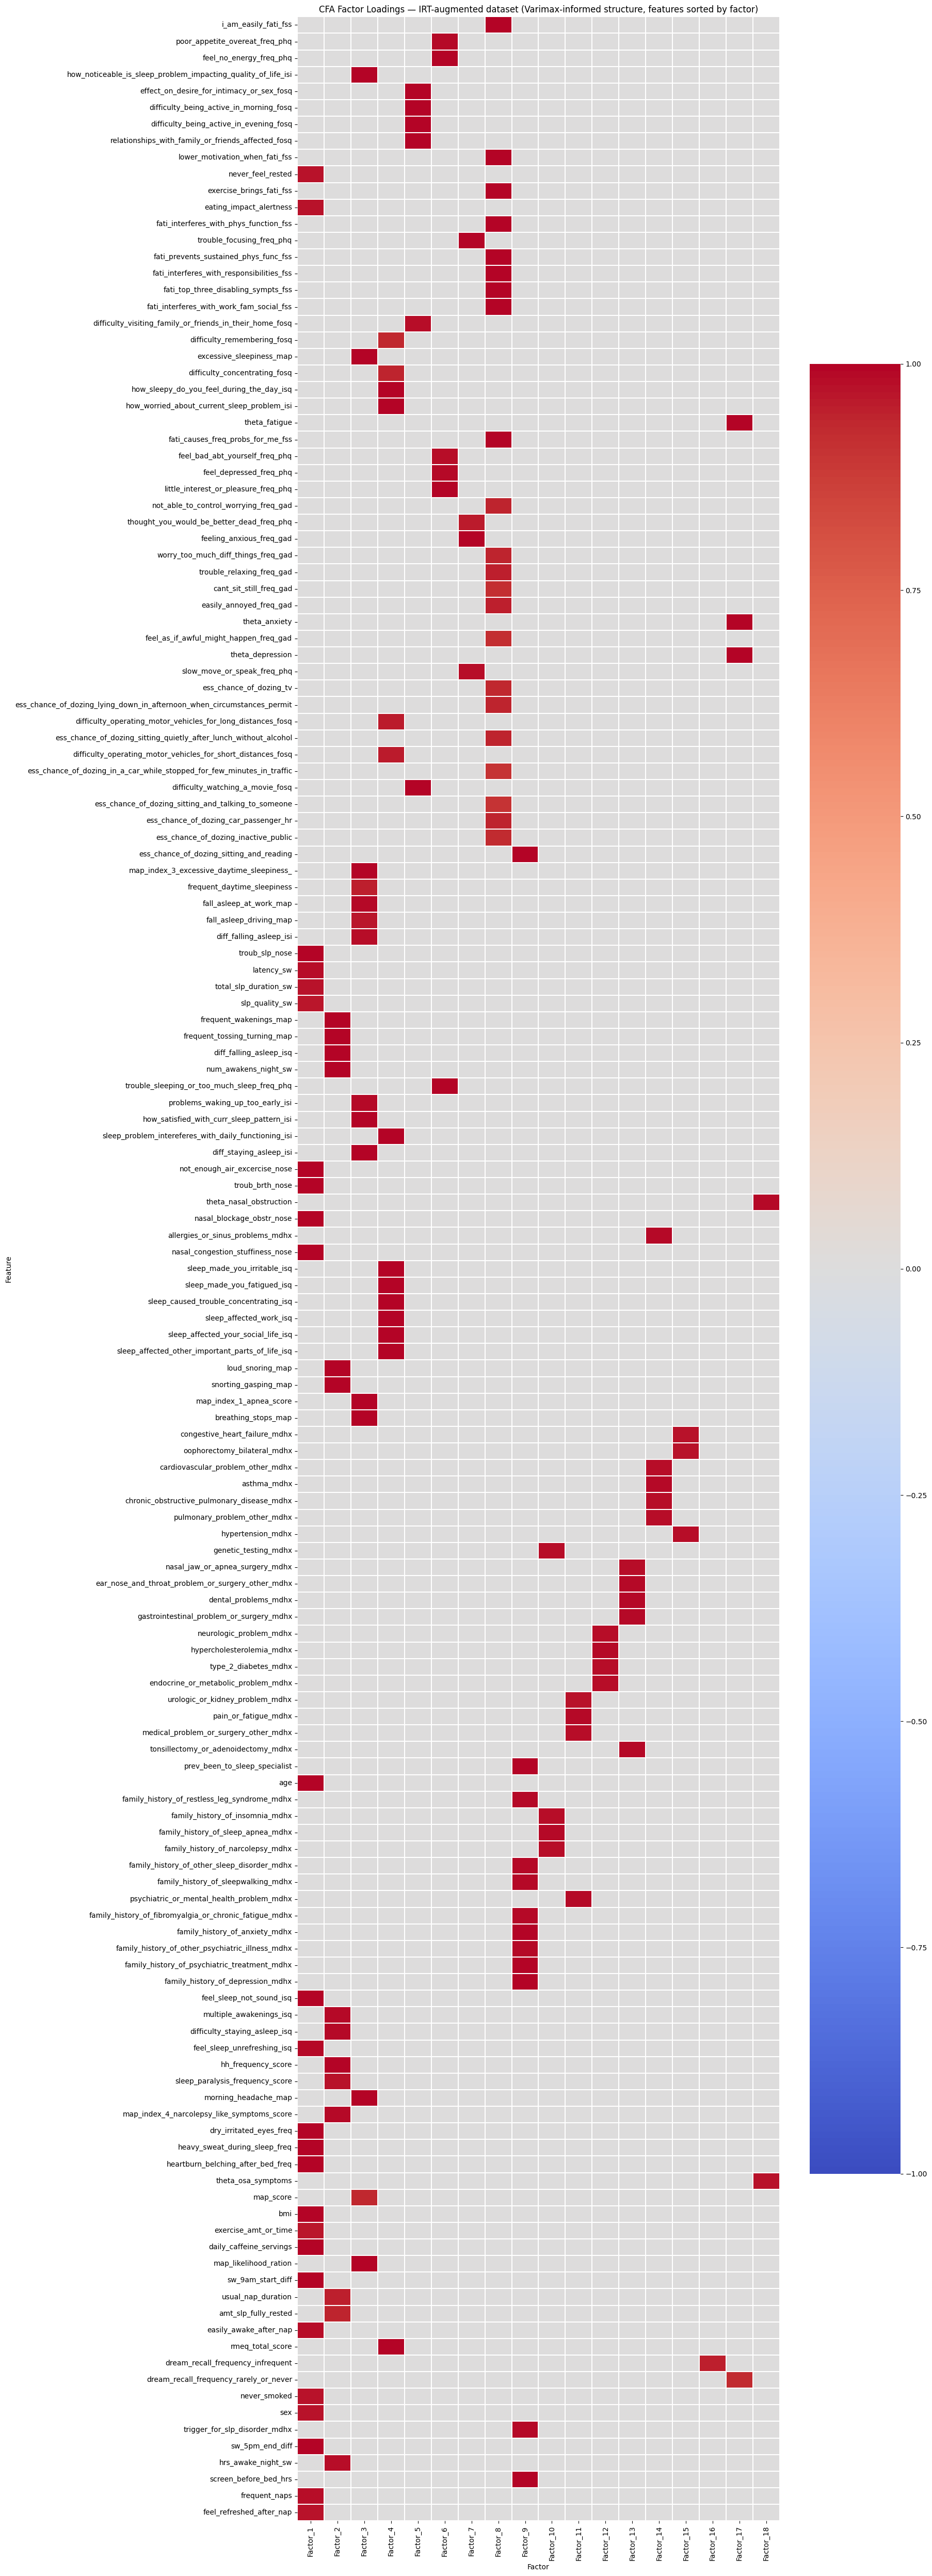

In [66]:
irt_cfa_loadings = pd.DataFrame(
    irt_cfa.loadings_,
    index=irt_aug_X.columns,
    columns=list(irt_model_dict.keys()),
)

# sort features by factor assignment → block-diagonal structure in heatmap
irt_sort_order = var_factor_assignments.map({col: i for i, col in enumerate(fa_var_loadings.columns)})
irt_sorted_features = irt_sort_order.sort_values().index
irt_cfa_loadings_sorted = irt_cfa_loadings.loc[irt_sorted_features]

"""fig, ax = plt.subplots(figsize=(18, max(10, len(irt_aug_X.columns) // 3)))
sns.heatmap(
    irt_cfa_loadings_sorted,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    ax=ax,
)
ax.set_title("CFA Factor Loadings — IRT-augmented dataset (Varimax-informed structure, features sorted by factor)")
ax.set_xlabel("Factor")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()"""

In [67]:
# ── EFA Varimax vs CFA peak loading comparison ────────────────────────────────
efa_var_peaks = fa_var_loadings.abs().max(axis=1).rename("efa_varimax_peak")
irt_cfa_peaks = irt_cfa_loadings.abs().max(axis=1).rename("cfa_peak")

comparison = pd.concat([efa_var_peaks, irt_cfa_peaks], axis=1)
comparison["delta"] = (comparison["cfa_peak"] - comparison["efa_varimax_peak"]).round(3)

print(f"Mean |Δ| peak loading (EFA → CFA): {comparison['delta'].abs().mean():.4f}")
print(f"Max  |Δ| peak loading:             {comparison['delta'].abs().max():.4f}")
print("\nTop 20 features by absolute change in peak loading (Varimax EFA − CFA):")
display(
    comparison
    .reindex(comparison["delta"].abs().sort_values(ascending=False).index)
    .head(20)
    .round(3)
    .style.background_gradient(subset=["delta"], cmap="RdBu", vmin=-0.4, vmax=0.4)
    .set_properties(**{"text-align": "right"})
)

Mean |Δ| peak loading (EFA → CFA): 0.4757
Max  |Δ| peak loading:             0.9120

Top 20 features by absolute change in peak loading (Varimax EFA − CFA):


,efa_varimax_peak,cfa_peak,delta
sw_5pm_end_diff,0.103000,1.015000,0.912000
daily_caffeine_servings,0.112000,1.013000,0.901000
trigger_for_slp_disorder_mdhx,0.112000,0.989000,0.877000
sw_9am_start_diff,0.131000,0.997000,0.866000
family_history_of_narcolepsy_mdhx,0.118000,0.977000,0.859000
congestive_heart_failure_mdhx,0.155000,0.972000,0.817000
eating_impact_alertness,0.173000,0.972000,0.799000
genetic_testing_mdhx,0.183000,0.981000,0.798000
family_history_of_other_sleep_disorder_mdhx,0.194000,0.988000,0.794000
asthma_mdhx,0.207000,0.988000,0.781000


In [68]:
# ── Global fit indices: RMSEA, CFI, SRMR ─────────────────────────────────────
# factor_analyzer uses ddof=0 (N divisor) for cov, so chi2 = n * F_ml
from numpy.linalg import slogdet

S_obs   = irt_cfa.cov_                     # sample covariance (ddof=0), (p×p)
Sigma_m = irt_cfa.get_model_implied_cov()  # model-implied covariance, (p×p)
n_obs   = irt_cfa.n_obs
p_vars  = S_obs.shape[0]

# ML discrepancy function
_, logdet_S   = slogdet(S_obs)
_, logdet_Sig = slogdet(Sigma_m)
Sigma_inv     = np.linalg.inv(Sigma_m)
F_ml  = logdet_Sig - logdet_S + np.trace(Sigma_inv @ S_obs) - p_vars
chi2  = n_obs * F_ml

# degrees of freedom: data moments − free parameters
n_free = (len(irt_cfa.model.loadings_free)
          + len(irt_cfa.model.error_vars_free)
          + len(irt_cfa.model.factor_covs_free))
df = p_vars * (p_vars + 1) // 2 - n_free

# null (independence) model: Σ_null = diag(S_obs), free params = p variances only
# F_null = log|diag(S)| − log|S|  (trace term cancels: trace(diag(S)^-1 @ S) = p)
logdet_diagS = np.sum(np.log(np.diag(S_obs)))
F_null    = logdet_diagS - logdet_S
chi2_null = n_obs * F_null
df_null   = p_vars * (p_vars - 1) // 2     # p*(p+1)/2 − p

# RMSEA = sqrt(max(F_ml − df/n, 0) / df)
rmsea = np.sqrt(max(chi2 - df, 0.0) / (n_obs * df))

# CFI (Bentler 1990): noncentrality-based incremental fit
cfi = float(np.clip(1.0 - max(chi2 - df, 0.0) / max(chi2_null - df_null, 1e-10), 0.0, 1.0))

# SRMR: standardised residual correlations (lower triangle including diagonal)
D_std = np.diag(1.0 / np.sqrt(np.diag(S_obs)))
R_obs = D_std @ S_obs   @ D_std   # observed correlation matrix
R_mod = D_std @ Sigma_m @ D_std   # model-implied correlation matrix
R_res = R_obs - R_mod              # residual correlations
lt_i, lt_j = np.tril_indices(p_vars, k=0)
srmr = np.sqrt(np.mean(R_res[lt_i, lt_j] ** 2))

print("CFA Global Fit Indices — IRT-augmented, 19-factor Varimax-informed structure")
print("=" * 75)
print(f"  χ²({df:>5d}) = {chi2:>10.2f}   (χ²/df = {chi2/df:.2f})")
print(f"  RMSEA      = {rmsea:.4f}   (good ≤ 0.06, acceptable ≤ 0.08)")
print(f"  CFI        = {cfi:.4f}   (good ≥ 0.95)")
print(f"  SRMR       = {srmr:.4f}   (good ≤ 0.08)")
print(f"\n  n_obs = {n_obs}   p = {p_vars}   df = {df}   n_free = {n_free}")
print(f"  AIC = {irt_cfa.aic_:.1f}   BIC = {irt_cfa.bic_:.1f}")

CFA Global Fit Indices — IRT-augmented, 19-factor Varimax-informed structure
  χ²(11021) =  581782.52   (χ²/df = 52.79)
  RMSEA      = 0.1752   (good ≤ 0.06, acceptable ≤ 0.08)
  CFI        = 0.0000   (good ≥ 0.95)
  SRMR       = 1.6093   (good ≤ 0.08)

  n_obs = 1687   p = 151   df = 11021   n_free = 455
  AIC = 1019212.9   BIC = 1036542.3


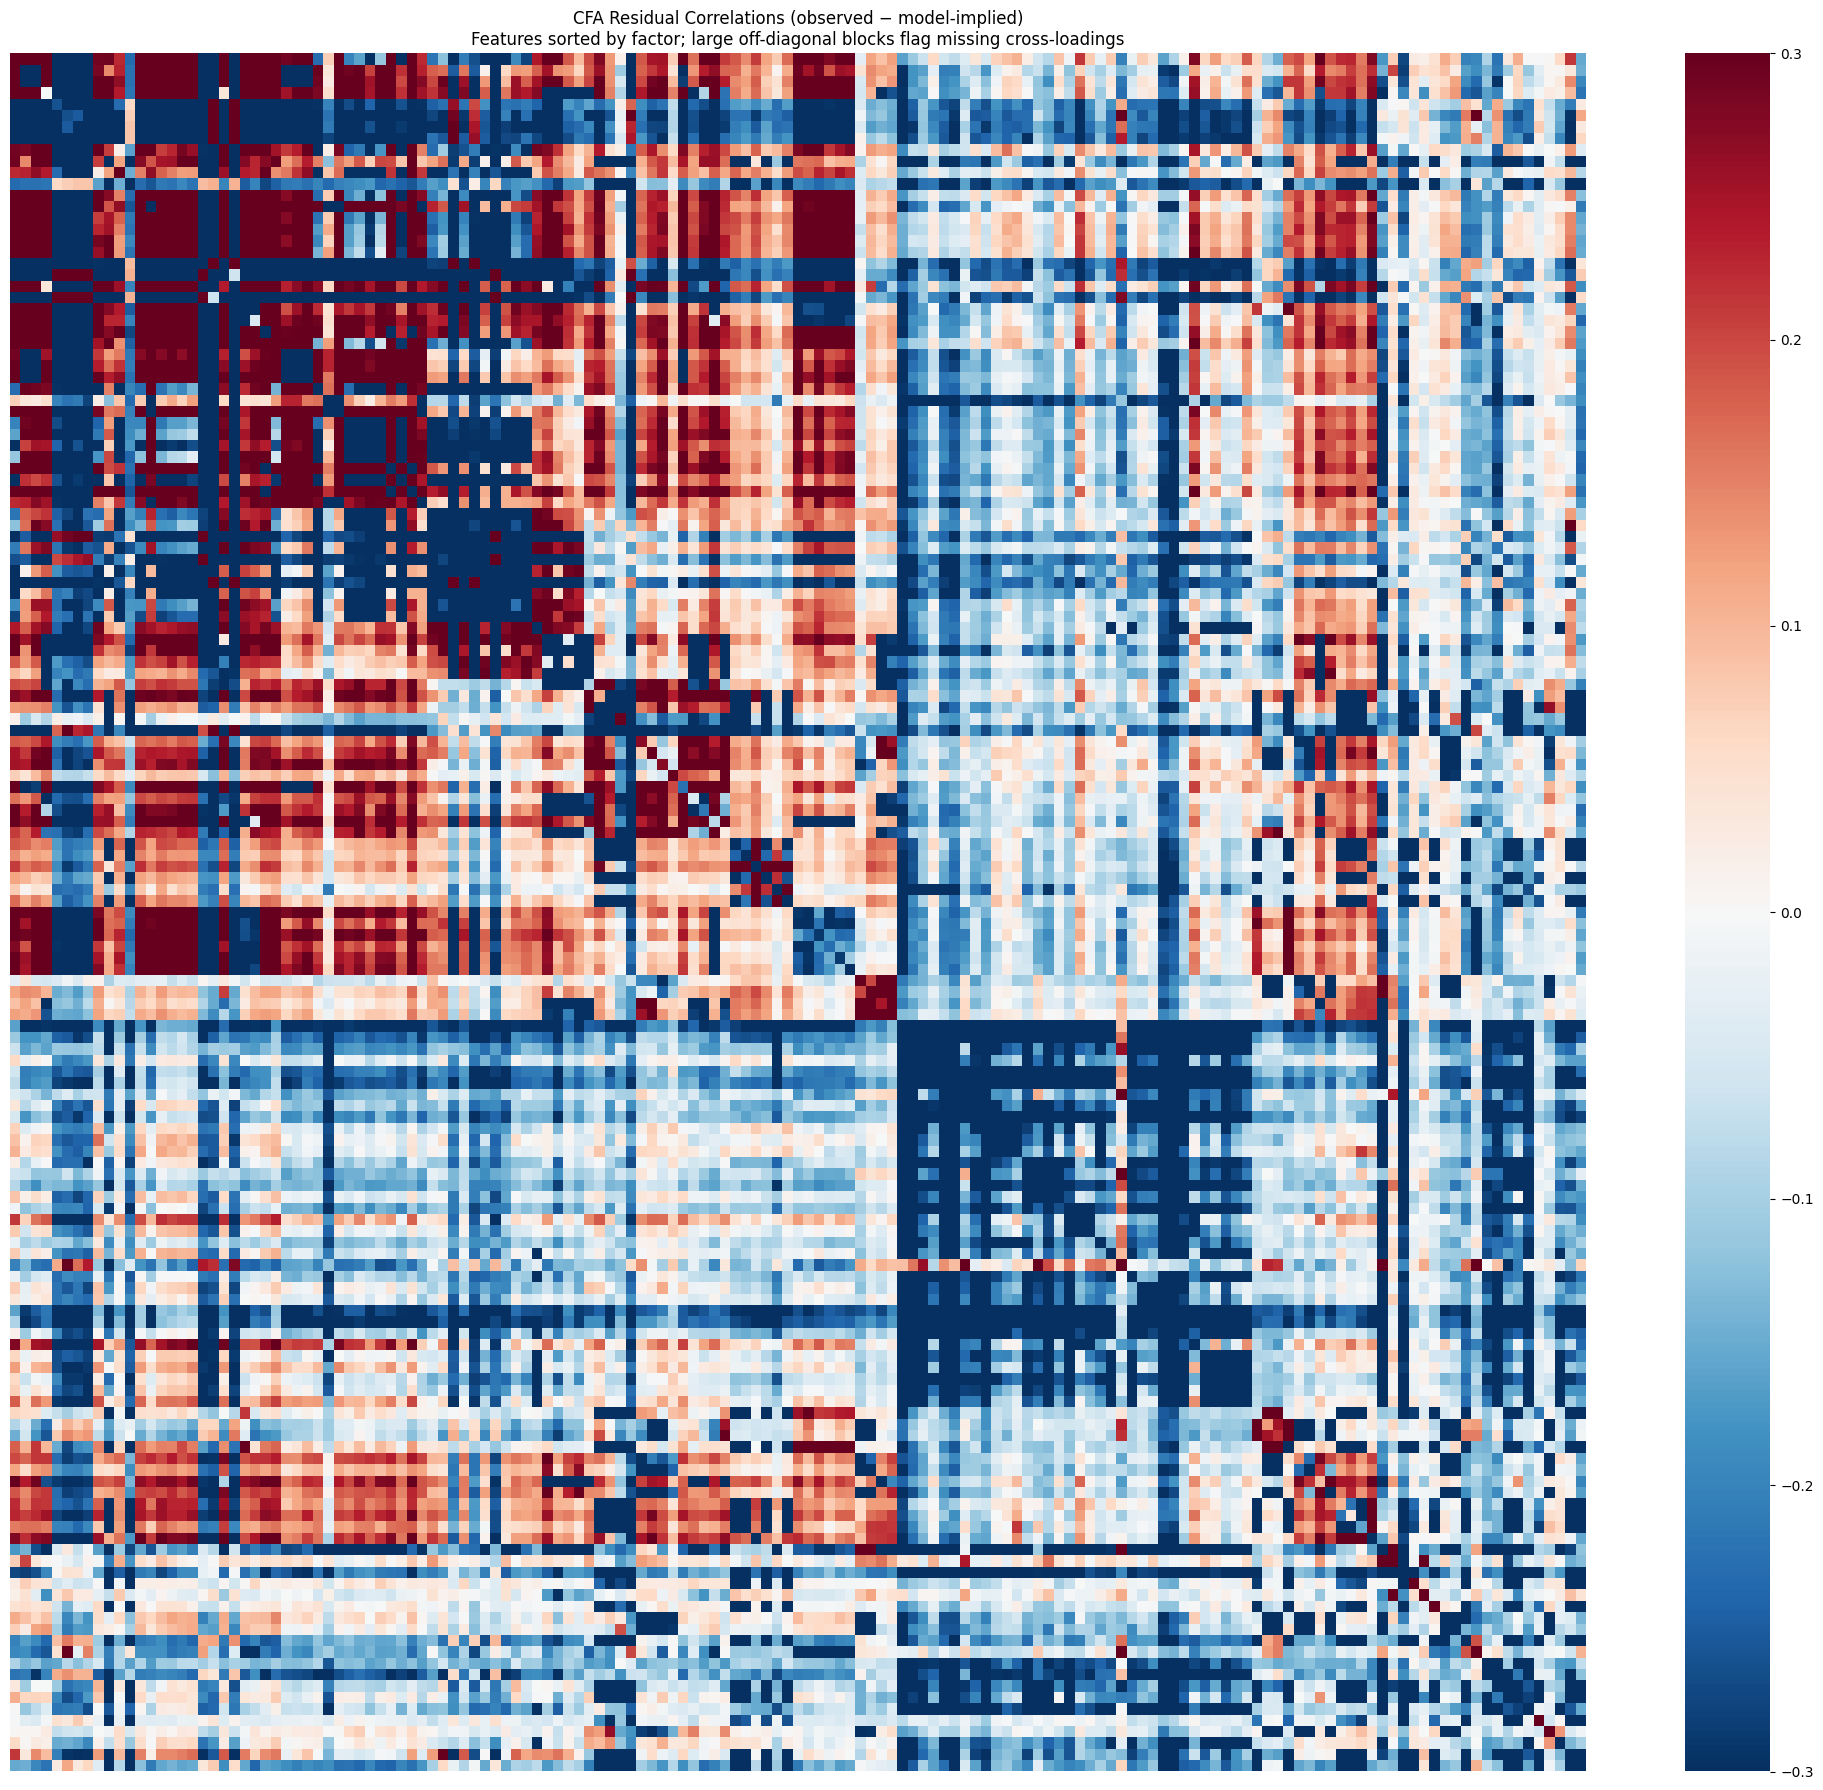

Off-diagonal residual correlations |r| > 0.10: 7053 / 11325 pairs  (62.3%)


,var1,var2,resid_r
10294,oophorectomy_bilateral_mdhx,congestive_heart_failure_mdhx,-32.055
9590,chronic_obstructive_pulmonary_disease_mdhx,pulmonary_problem_other_mdhx,-25.144
7500,genetic_testing_mdhx,family_history_of_narcolepsy_mdhx,-19.996
6902,family_history_of_other_sleep_disorder_mdhx,family_history_of_sleepwalking_mdhx,-19.558
6898,family_history_of_other_sleep_disorder_mdhx,family_history_of_other_psychiatric_illness_mdhx,-19.077
6895,family_history_of_other_sleep_disorder_mdhx,trigger_for_slp_disorder_mdhx,-18.387
7020,family_history_of_restless_leg_syndrome_mdhx,family_history_of_other_sleep_disorder_mdhx,-17.051
6901,family_history_of_other_sleep_disorder_mdhx,family_history_of_fibromyalgia_or_chronic_fati...,-16.567
7379,family_history_of_insomnia_mdhx,family_history_of_narcolepsy_mdhx,-16.346
9867,cardiovascular_problem_other_mdhx,pulmonary_problem_other_mdhx,-15.634


In [69]:
# ── Residual correlation heatmap ──────────────────────────────────────────────
# R_res defined in the fit-indices cell above; irt_sorted_features from heatmap cell
R_resid_df     = pd.DataFrame(R_res, index=irt_aug_X.columns, columns=irt_aug_X.columns)
R_resid_sorted = R_resid_df.loc[irt_sorted_features, irt_sorted_features]

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    R_resid_sorted,
    cmap="RdBu_r",
    center=0,
    vmin=-0.3,
    vmax=0.3,
    linewidths=0,
    ax=ax,
    xticklabels=False,
    yticklabels=False,
)
ax.set_title(
    "CFA Residual Correlations (observed − model-implied)\n"
    "Features sorted by factor; large off-diagonal blocks flag missing cross-loadings"
)
plt.tight_layout()
plt.show()

# ── table: worst off-diagonal residuals ───────────────────────────────────────
cols_       = list(irt_aug_X.columns)
lt_i_off, lt_j_off = np.tril_indices(p_vars, k=-1)   # strictly lower triangle
pairs_ = [(cols_[i], cols_[j], R_res[i, j]) for i, j in zip(lt_i_off, lt_j_off)]
resid_pairs = (
    pd.DataFrame(pairs_, columns=["var1", "var2", "resid_r"])
    .assign(abs_resid=lambda d: d["resid_r"].abs())
    .sort_values("abs_resid", ascending=False)
)
n_large = (resid_pairs["abs_resid"] > 0.10).sum()
print(f"Off-diagonal residual correlations |r| > 0.10: {n_large} / {len(resid_pairs)} pairs  "
      f"({n_large / len(resid_pairs) * 100:.1f}%)")
display(resid_pairs[resid_pairs["abs_resid"] > 0.10].drop(columns="abs_resid").head(20).round(3))

In [70]:
# ── Per-factor reliability: Cronbach's α and McDonald's ω ────────────────────
# α: from observed sub-covariance matrix (scale-free reliability estimate)
# ω: composite reliability from CFA loadings + error variances
#    ω = (Σλ_i)² / ((Σλ_i)² + Σθ_i)   — proportion of factor-explained variance

S_obs_df  = pd.DataFrame(irt_cfa.cov_, index=irt_aug_X.columns, columns=irt_aug_X.columns)
err_vars  = irt_cfa.error_vars_.flatten()   # (n_variables,)
all_vars  = list(irt_aug_X.columns)
fac_names = list(irt_model_dict.keys())

rel_rows = []
for factor_name, items in irt_model_dict.items():
    k          = len(items)
    factor_idx = fac_names.index(factor_name)
    item_idxs  = [all_vars.index(v) for v in items]

    # Cronbach's α
    if k >= 2:
        S_sub     = S_obs_df.loc[items, items].values
        total_var = S_sub.sum()
        item_var  = np.diag(S_sub).sum()
        alpha = (k / (k - 1)) * (1 - item_var / total_var) if total_var > 0 else np.nan
    else:
        alpha = np.nan

    # McDonald's ω (composite reliability)
    lam       = irt_cfa.loadings_[item_idxs, factor_idx]   # (k,) loadings on this factor
    theta     = err_vars[item_idxs]                         # (k,) error variances
    sum_lam_sq = lam.sum() ** 2
    denom      = sum_lam_sq + theta.sum()
    omega      = float(sum_lam_sq / denom) if denom > 0 else np.nan

    rel_rows.append({
        "factor":         factor_name,
        "n_items":        k,
        "cronbach_alpha": round(float(alpha), 3) if not np.isnan(alpha) else np.nan,
        "mcdonald_omega": round(omega, 3) if not np.isnan(omega) else np.nan,
    })

rel_df = pd.DataFrame(rel_rows).sort_values("mcdonald_omega", ascending=False)

print("Per-factor reliability  (acceptable ≥ 0.70, good ≥ 0.80)")
display(
    rel_df.style
    .background_gradient(subset=["cronbach_alpha", "mcdonald_omega"], cmap="RdYlGn", vmin=0, vmax=1)
    .format({"cronbach_alpha": "{:.3f}", "mcdonald_omega": "{:.3f}"})
    .set_properties(**{"text-align": "right"})
)
print(f"\nMedian α = {rel_df['cronbach_alpha'].median():.3f}   "
      f"Median ω = {rel_df['mcdonald_omega'].median():.3f}")
print(f"Factors with ω < 0.70: {(rel_df['mcdonald_omega'] < 0.70).sum()} / {len(rel_df)}")

Per-factor reliability  (acceptable ≥ 0.70, good ≥ 0.80)


,factor,n_items,cronbach_alpha,mcdonald_omega
8,Factor_9,12,0.729,0.922
2,Factor_3,15,0.719,0.647
0,Factor_1,26,0.848,0.199
3,Factor_4,14,0.745,0.100
11,Factor_12,4,0.757,0.000
16,Factor_17,4,0.009,0.000
15,Factor_16,1,nan,0.000
14,Factor_15,3,-1.394,0.000
13,Factor_14,5,-0.362,0.000
12,Factor_13,5,0.386,0.000



Median α = 0.745   Median ω = 0.000
Factors with ω < 0.70: 17 / 18


In [72]:
# ── CFA factor scores → dataset ───────────────────────────────────────────────
irt_cfa_scores = irt_cfa.transform(irt_aug_X.values)
_irt_cfa_cols  = list(irt_model_dict.keys())

irt_cfa_df = pd.DataFrame(irt_cfa_scores, index=irt_aug_X.index, columns=_irt_cfa_cols)
irt_cfa_df["ahi"] = irt_aug_df["ahi"].values

irt_cfa_dataset_path = "../../data/processed/mlflow/mlflow_irt_cfa_dataset_v1.csv"
irt_cfa_df.to_csv(irt_cfa_dataset_path, index=False)

irt_cfa_mlflow_ds = mlflow.data.from_pandas(
    irt_cfa_df, source=irt_cfa_dataset_path, name="irt_cfa_dataset_v1", targets="ahi"
)

irt_cfa_X = irt_cfa_df.drop(columns=["ahi"])
irt_cfa_y = convert_ahi(irt_cfa_df["ahi"], threshold=15)
irt_cfa_X_train, irt_cfa_test_X, irt_cfa_train_y, irt_cfa_test_y = train_test_split(
    irt_cfa_X, irt_cfa_y, test_size=0.2, random_state=42, stratify=irt_cfa_y
)

print(f"IRT-CFA factor scores dataset saved → {irt_cfa_dataset_path}")
print(f"Shape: {irt_cfa_df.shape}  ({len(_irt_cfa_cols)} CFA factor score cols)")
print(f"Train: {irt_cfa_X_train.shape}   Test: {irt_cfa_test_X.shape}")
display(irt_cfa_df.head())

IRT-CFA factor scores dataset saved → ../../data/processed/mlflow/mlflow_irt_cfa_dataset_v1.csv
Shape: (1687, 19)  (18 CFA factor score cols)
Train: (1349, 18)   Test: (338, 18)


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15,Factor_16,Factor_17,Factor_18,ahi
0,-0.035985,-0.119327,-0.319899,0.112377,0.657765,-0.437184,-0.038584,-0.144171,-0.158529,-0.170646,-0.280938,-0.172899,-0.255635,-0.163046,-0.132092,-0.292254,0.042470,-0.220729,0.3
1,-0.269670,-1.032645,-0.374181,0.475102,-1.695846,0.257965,-0.288199,0.564182,0.203455,0.334235,0.737152,-0.172899,-0.255635,-0.163046,-0.132092,0.758988,0.173210,-0.191596,0.4
2,-0.265498,0.243830,0.505065,0.818293,-0.010257,-0.925272,0.214737,-0.186480,-0.130857,-0.170646,-0.280938,-0.172899,0.352551,-0.163046,-0.132092,-0.292254,-0.102364,-0.330237,1.0
3,-0.055565,0.497297,-0.363268,-0.368785,-0.014422,-0.600052,1.234773,-0.874005,0.114302,-0.170646,0.226913,-0.172899,-0.054719,-0.163046,-0.132092,-0.292254,-0.119688,-0.158215,3.9
4,-0.257284,-0.617979,-0.522842,0.085575,-0.336464,-0.251583,-0.038584,-0.275592,0.182537,0.334235,-0.027190,-0.172899,-0.054848,0.035751,0.204968,-0.292254,0.189649,-0.219564,1.3


In [ ]:
irt_cfa_df = cfa_df.copy()
for theta_name, scores in theta_scores.items():
    irt_cfa_df[theta_name] = scores

irt_cfa_path = "../../data/processed/mlflow/mlflow_irt_cfa_dataset_v1.csv"
irt_cfa_df.to_csv(irt_cfa_path, index=False)
print(f"IRT-CFA dataset: {irt_cfa_df.shape}")

irt_cfa_mlflow_ds = mlflow.data.from_pandas(irt_cfa_df, source=irt_cfa_path, name="irt_cfa_v1", targets="ahi")

irt_cfa_X = irt_cfa_df.drop(columns=["ahi"])
irt_cfa_y = convert_ahi(irt_cfa_df["ahi"], threshold=15)
irt_cfa_X_train, irt_cfa_test_X, irt_cfa_train_y, irt_cfa_test_y = train_test_split(
    irt_cfa_X, irt_cfa_y, test_size=0.2, random_state=42, stratify=irt_cfa_y
)

irt_cfa_trials = [
    ("irt_augmented_full",  irt_aug_mlflow_ds, irt_aug_X_train,  irt_aug_test_X,  irt_aug_train_y,  irt_aug_test_y),
    ("irt_cfa_factors",     irt_cfa_mlflow_ds, irt_cfa_X_train, irt_cfa_test_X,  irt_cfa_train_y, irt_cfa_test_y),
]

experiment_irt_cfa = _setup_experiment("dataset-comparison-irt-cfa-v1", {
    "description": "IRT-augmented CFA factor scores vs IRT-augmented full dataset — RF and HGB",
    "feature_engineering": "CFA-varimax-19-factors-irt",
})
_run_mlflow_trials(irt_cfa_trials, model_configs, log_shap=False)


dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------
irt_augmented_full         rf       0.651   0.600   0.289   0.460         151
irt_augmented_full         hgb      0.612   0.544   0.367   0.395         151
irt_cfa_factors            rf       0.624   0.541   0.314   0.393          18
irt_cfa_factors            hgb      0.598   0.560   0.419   0.391          18


## Oblique CFA — Promax rotation + freed cross-loadings

The simple-structure Varimax CFA constrains each variable to one factor and forces orthogonality. Two improvements:

1. **Promax rotation** (oblique) — refits the EFA allowing factors to correlate, giving factor assignments that reflect natural clinical clusters rather than enforcing independence
2. **Freed cross-loadings** — variables with a secondary Promax loading ≥ 0.32 are allowed to load on that factor too, reducing residual correlations

Expected effects: lower RMSEA/SRMR, higher CFI, and lower AIC (better likelihood per free parameter).

In [75]:
# ── Promax EFA ────────────────────────────────────────────────────────────────
from factor_analyzer import ModelSpecification

CROSS_THRESHOLD = 0.32   # |λ| cutoff for freeing secondary loadings

fa_promax = FactorAnalyzer(n_factors=19, rotation="promax")
fa_promax.fit(irt_aug_X)
fa_promax_loadings = pd.DataFrame(
    fa_promax.loadings_, index=irt_aug_X.columns, columns=_factor_cols
)

# ── build loading indicator matrix: primary always free; secondary freed if ≥ threshold
loadings_mask = (fa_promax_loadings.abs() >= CROSS_THRESHOLD).astype(int).values
primary_fac_idx = fa_promax_loadings.abs().values.argmax(axis=1)
for var_i, fac_j in enumerate(primary_fac_idx):
    loadings_mask[var_i, fac_j] = 1      # guarantee primary is always free

n_cross = int(loadings_mask.sum()) - irt_aug_X.shape[1]
print(f"Promax structure: {n_cross} cross-loadings freed (|λ| ≥ {CROSS_THRESHOLD})")
print(f"Total free loading params: {int(loadings_mask.sum())}  "
      f"(simple structure had {irt_aug_X.shape[1]})")

# ── fit oblique CFA ────────────────────────────────────────────────────────────
promax_spec = ModelSpecification(
    loadings=loadings_mask,
    n_factors=19,
    n_variables=irt_aug_X.shape[1],
    factor_names=_factor_cols,
    variable_names=list(irt_aug_X.columns),
)

irt_cfa_oblique = ConfirmatoryFactorAnalyzer(promax_spec, disp=False, max_iter=2000)
irt_cfa_oblique.fit(irt_aug_X.values)

print(f"\n{'Model':<38}  {'Log-lik':>12}  {'AIC':>12}  {'BIC':>12}")
print("-" * 78)
print(f"{'Varimax simple-structure CFA':<38}  {irt_cfa.log_likelihood_:>12.2f}  "
      f"{irt_cfa.aic_:>12.1f}  {irt_cfa.bic_:>12.1f}")
print(f"{'Promax oblique CFA':<38}  {irt_cfa_oblique.log_likelihood_:>12.2f}  "
      f"{irt_cfa_oblique.aic_:>12.1f}  {irt_cfa_oblique.bic_:>12.1f}")
print("\n(Lower AIC = better fit adjusted for complexity; lower BIC penalises params more)")

Promax structure: 17 cross-loadings freed (|λ| ≥ 0.32)
Total free loading params: 168  (simple structure had 151)

Model                                        Log-lik           AIC           BIC
------------------------------------------------------------------------------
Varimax simple-structure CFA              -506415.45     1019212.9     1036542.3
Promax oblique CFA                        -460226.66      927175.3      945427.9

(Lower AIC = better fit adjusted for complexity; lower BIC penalises params more)


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/factor_analyzer/confirmatory_factor_analyzer.py:753: UserWarning: The optimization routine failed to converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
  warnings.warn(


In [76]:
# ── Global fit indices: oblique CFA vs Varimax CFA ───────────────────────────
# Reuse chi2_null / df_null already computed in the earlier fit-indices cell
from numpy.linalg import slogdet as _slogdet

S_obl   = irt_cfa_oblique.cov_
Sig_obl = irt_cfa_oblique.get_model_implied_cov()
n_obl   = irt_cfa_oblique.n_obs
p_obl   = S_obl.shape[0]

_, ld_S_obl   = _slogdet(S_obl)
_, ld_Sig_obl = _slogdet(Sig_obl)
F_obl    = ld_Sig_obl - ld_S_obl + np.trace(np.linalg.inv(Sig_obl) @ S_obl) - p_obl
chi2_obl = n_obl * F_obl

n_free_obl = (len(irt_cfa_oblique.model.loadings_free)
              + len(irt_cfa_oblique.model.error_vars_free)
              + len(irt_cfa_oblique.model.factor_covs_free))
df_obl = p_obl * (p_obl + 1) // 2 - n_free_obl

rmsea_obl = np.sqrt(max(chi2_obl - df_obl, 0.0) / (n_obl * df_obl))
cfi_obl   = float(np.clip(
    1.0 - max(chi2_obl - df_obl, 0.0) / max(chi2_null - df_null, 1e-10), 0.0, 1.0
))

D_obl     = np.diag(1.0 / np.sqrt(np.diag(S_obl)))
R_obs_obl = D_obl @ S_obl   @ D_obl
R_mod_obl = D_obl @ Sig_obl @ D_obl
R_res_obl = R_obs_obl - R_mod_obl
lt_i_obl, lt_j_obl = np.tril_indices(p_obl, k=0)
srmr_obl = np.sqrt(np.mean(R_res_obl[lt_i_obl, lt_j_obl] ** 2))

print("Fit index comparison — Varimax simple-structure vs Promax oblique CFA")
print("=" * 70)
print(f"\n{'Index':<8}  {'Varimax':>10}  {'Promax':>10}  {'Change':>12}  {'Interpretation'}")
print("-" * 70)

def _arrow(better_when, val_new, val_old):
    improved = val_new < val_old if better_when == 'lower' else val_new > val_old
    return f"{'↓' if better_when=='lower' else '↑'} {'better' if improved else 'worse'}"

print(f"{'RMSEA':<8}  {rmsea:>10.4f}  {rmsea_obl:>10.4f}  "
      f"{rmsea_obl - rmsea:>+12.4f}  {_arrow('lower', rmsea_obl, rmsea)}")
print(f"{'CFI':<8}  {cfi:>10.4f}  {cfi_obl:>10.4f}  "
      f"{cfi_obl - cfi:>+12.4f}  {_arrow('higher', cfi_obl, cfi)}")
print(f"{'SRMR':<8}  {srmr:>10.4f}  {srmr_obl:>10.4f}  "
      f"{srmr_obl - srmr:>+12.4f}  {_arrow('lower', srmr_obl, srmr)}")
print(f"\n  df  :  {df:>8d}     {df_obl:>8d}   ({n_free_obl - n_free} additional free params)")
print(f"  AIC :  {irt_cfa.aic_:>10.1f}  {irt_cfa_oblique.aic_:>10.1f}")

Fit index comparison — Varimax simple-structure vs Promax oblique CFA

Index        Varimax      Promax        Change  Interpretation
----------------------------------------------------------------------
RMSEA         0.1752      0.1607       -0.0145  ↓ better
CFI           0.0000      0.0000       +0.0000  ↑ worse
SRMR          1.6093      2.2010       +0.5917  ↓ worse

  df  :     11021        10986   (35 additional free params)
  AIC :   1019212.9    927175.3


In [ ]:
N_OBL_FACTORS = 19

fa_obl = FactorAnalyzer(n_factors=N_OBL_FACTORS, rotation="promax")
fa_obl.fit(irt_aug_X)
loadings_obl = pd.DataFrame(fa_obl.loadings_, index=irt_aug_X.columns,
                            columns=[f"F{i+1}" for i in range(N_OBL_FACTORS)])

cross_mask = (loadings_obl.abs() > 0.30).sum(axis=1) > 1
print(f"Items with cross-loadings (|loading| > 0.30 on >1 factor): {cross_mask.sum()}")

obl_items = irt_aug_X.columns[~cross_mask].tolist()
fa_obl_clean = FactorAnalyzer(n_factors=N_OBL_FACTORS, rotation="promax")
fa_obl_clean.fit(irt_aug_X[obl_items])
obl_scores = fa_obl_clean.transform(irt_aug_X[obl_items])

obl_df = irt_aug_df[["ahi"]].copy()
for i in range(N_OBL_FACTORS):
    obl_df[f"obl_F{i+1}"] = obl_scores[:, i]

obl_path = "../../data/processed/mlflow/mlflow_irt_cfa_oblique_v1.csv"
obl_df.to_csv(obl_path, index=False)
print(f"Oblique CFA dataset: {obl_df.shape}")

obl_mlflow_ds = mlflow.data.from_pandas(obl_df, source=obl_path, name="irt_cfa_oblique_v1", targets="ahi")

obl_X = obl_df.drop(columns=["ahi"])
obl_y = convert_ahi(obl_df["ahi"], threshold=15)
obl_X_train, obl_test_X, obl_train_y, obl_test_y = train_test_split(
    obl_X, obl_y, test_size=0.2, random_state=42, stratify=obl_y
)

obl_trials = [
    ("irt_augmented_full",  irt_aug_mlflow_ds, irt_aug_X_train, irt_aug_test_X, irt_aug_train_y, irt_aug_test_y),
    ("irt_cfa_varimax",     irt_cfa_mlflow_ds, irt_cfa_X_train, irt_cfa_test_X, irt_cfa_train_y, irt_cfa_test_y),
    ("irt_cfa_oblique",     obl_mlflow_ds,     obl_X_train,     obl_test_X,     obl_train_y,     obl_test_y),
]

experiment_obl = _setup_experiment("dataset-comparison-irt-cfa-oblique-v1", {
    "description": "Oblique CFA (Promax + cross-loadings) vs Varimax CFA vs IRT-augmented full",
    "feature_engineering": "CFA-promax-19-factors-cross-loadings",
})
_run_mlflow_trials(obl_trials, model_configs, log_shap=False)


/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
2026/05/28 13:23:59 INFO mlflow.tracking.fluent: Experiment with name 'dataset-comparison-irt-cfa-oblique-v1' does not exist. Creating a new experiment.


Oblique CFA scores dataset saved → ../../data/processed/mlflow/mlflow_irt_cfa_oblique_v1.csv
Train: (1349, 19)   Test: (338, 19)

dataset                    model      acc     auc      f1   auprc  n_features
------------------------------------------------------------------------------
irt_augmented_full         rf       0.651   0.600   0.289   0.460         151
irt_augmented_full         hgb      0.612   0.544   0.367   0.395         151
irt_cfa_varimax            rf       0.624   0.541   0.314   0.393          18
irt_cfa_varimax            hgb      0.598   0.560   0.419   0.391          18
irt_cfa_oblique            rf       0.630   0.541   0.317   0.412          19
irt_cfa_oblique            hgb      0.589   0.532   0.347   0.380          19
